# Auto-correlation

This section tests the scalar non-uniform KTZ model and retains its original numerical setup.


In [1]:
# %% Block 1: Import packages and set global parameters
import numpy as np
from numpy.random import default_rng
from scipy.special import exp1
from scipy.integrate import quad
from scipy.interpolate import RegularGridInterpolator, interp1d
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

# M101-like fiducial setup, calibrated to the observed star-forming main disc.
# M101 has an extended faint outer disc, but this notebook uses the brighter main disc
# where HII-region and spiral-arm measurements are better sampled.
R_in, R_out = 3.0, 15

# Diffusion parameters.  These control the KTZ smoothing scale,
# ell_K = sqrt(x0^2 + 2 kappa t), rather than direct observables.
kappa = 0.3579         # kpc^2/Gyr (same as KT25)
x0 = 0.10            # initial smoothing length (kpc)
t_star = 0.50        # maximum source age (Gyr)

# Spiral structure.  M101 is asymmetric and multi-armed; pitch angles vary by segment.
# A single logarithmic spiral is only a fiducial approximation.  Try 15, 20, and 25 deg.
m_arms = 3
pitch_angle = 20.0   # degree
pitch_rad = np.deg2rad(pitch_angle)
Theta0 = 0.0

# Spiral arm modulation h(Theta) = sum_n g_n cos(n Theta + alpha_n).
# Keep all harmonic parameters here; the numerical source rate and KTZ theory
# blocks read these arrays directly.
eta = 0.40
harmonic_n = np.array([1, 2, 3], dtype=int)
harmonic_g = np.array([1.00, 0.40, 0.20], dtype=float)
harmonic_alpha = np.array([0.00, 0.00, 0.00], dtype=float)

def h_func(Theta):
    Theta = np.asarray(Theta)
    h_val = np.zeros_like(Theta, dtype=float)
    for n, g, alpha in zip(harmonic_n, harmonic_g, harmonic_alpha):
        h_val = h_val + g*np.cos(n*Theta + alpha)
    return h_val

Theta_check = np.linspace(0, 2*np.pi, 4096, endpoint=False)
rate_floor = 1.0 + eta*np.min(h_func(Theta_check))
if rate_floor <= 0:
    raise ValueError("Spiral harmonic settings make lambda_rate negative; lower eta or harmonic_g.")

# Background rate $\lambda_0(\varpi) = \lambda_{00} \exp(-\varpi/h_R)$.
# h_R approx 4.8 kpc follows the main-disc boundary at roughly three scale lengths.
# lambda0_0 is an effective event rate; rescale it if one synthetic event represents
# a different stellar mass or yield unit.
lambda0_0 = 5.0e2   # kpc^-2 Gyr^-1
h_R = 4.8

# Source clustering.  The clustered component is a Thomas process:
# parent complexes are sampled from the same mean spiral-modulated rate,
# and child enrichment events are scattered around each parent.
enable_source_clustering = True
cluster_fraction = 0.50              # fraction of events drawn from clustered complexes
cluster_radius = 0.35                # kpc, one-sigma child offset around each parent
mean_children_per_cluster = 20.0      # mean child events per parent complex
cluster_theory_nodes = 24            # quadrature nodes for the C_NP age integral

# Output (fixed)
Y_val = 1.0

# Computational grid.
dx = 0.20
grid_radius = R_out + 1.0

# Number of independent numerical realizations used to estimate error bands.
# Increase this for publication-quality uncertainty estimates.
n_realizations = 10

rng = default_rng(42)

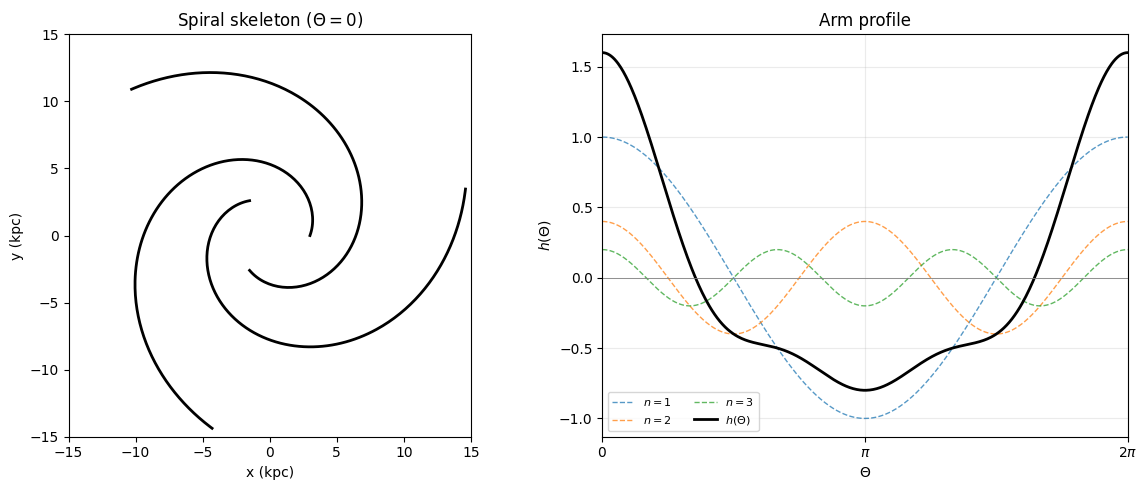

In [2]:
# %% Section 2: Definition of auxiliary functions (spiral phase, source rate, wavenumber)
def spiral_phase(varpi, phi):
    r"""The phase of a logarithmic spiral $\Theta$."""
    Phi = (m_arms / np.tan(pitch_rad)) * np.log(varpi / R_in)
    return Phi - m_arms * phi + Theta0

def lambda_rate(varpi, phi):
    r"""Non-uniform event rate $\lambda(\varpi,\phi)$."""
    lam0 = lambda0_0 * np.exp(-varpi / h_R)
    Theta = spiral_phase(varpi, phi)
    return lam0 * (1.0 + eta * h_func(Theta))

def k_perp(varpi):
    r"""Local arm-normal wavenumber $k_\perp$."""
    dPhi = (m_arms / np.tan(pitch_rad)) / varpi
    return np.sqrt(dPhi**2 + (m_arms / varpi)**2)

# Visualising the spiral pattern and its arm-profile harmonics.
varpi_plot = np.linspace(R_in, R_out, 200)
profile_theta = np.linspace(0, 2*np.pi, 600)
profile_total = h_func(profile_theta)

fig, (ax_spiral, ax_profile) = plt.subplots(1, 2, figsize=(12, 5))
for k in range(m_arms):
    # Solve Phi(varpi) - m*phi + Theta0 = 0 -> phi = (Phi(varpi) + Theta0 + 2*pi*k)/m.
    phi_sp = ((m_arms / np.tan(pitch_rad)) * np.log(varpi_plot / R_in) + Theta0 + 2*np.pi*k) / m_arms
    ax_spiral.plot(varpi_plot * np.cos(phi_sp), varpi_plot * np.sin(phi_sp), 'k-', lw=2)
ax_spiral.set_xlim(-R_out, R_out)
ax_spiral.set_ylim(-R_out, R_out)
ax_spiral.set_aspect('equal')
ax_spiral.set_title(r'Spiral skeleton ($\Theta = 0$)')
ax_spiral.set_xlabel('x (kpc)')
ax_spiral.set_ylabel('y (kpc)')

for n, g, alpha in zip(harmonic_n, harmonic_g, harmonic_alpha):
    component = g*np.cos(n*profile_theta + alpha)
    ax_profile.plot(profile_theta, component, '--', lw=1, alpha=0.75, label=fr'$n={n}$')
ax_profile.plot(profile_theta, profile_total, 'k-', lw=2, label=r'$h(\Theta)$')
ax_profile.axhline(0, color='grey', lw=0.6)
ax_profile.set_xlim(0, 2*np.pi)
ax_profile.set_xticks([0, np.pi, 2*np.pi])
ax_profile.set_xticklabels([r'$0$', r'$\pi$', r'$2\pi$'])
ax_profile.set_xlabel(r'$\Theta$')
ax_profile.set_ylabel(r'$h(\Theta)$')
ax_profile.set_title(r'Arm profile')
ax_profile.grid(alpha=0.25)
ax_profile.legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.show()


Expected number of events: 24920, realization 1: 25053 (12381 clustered)


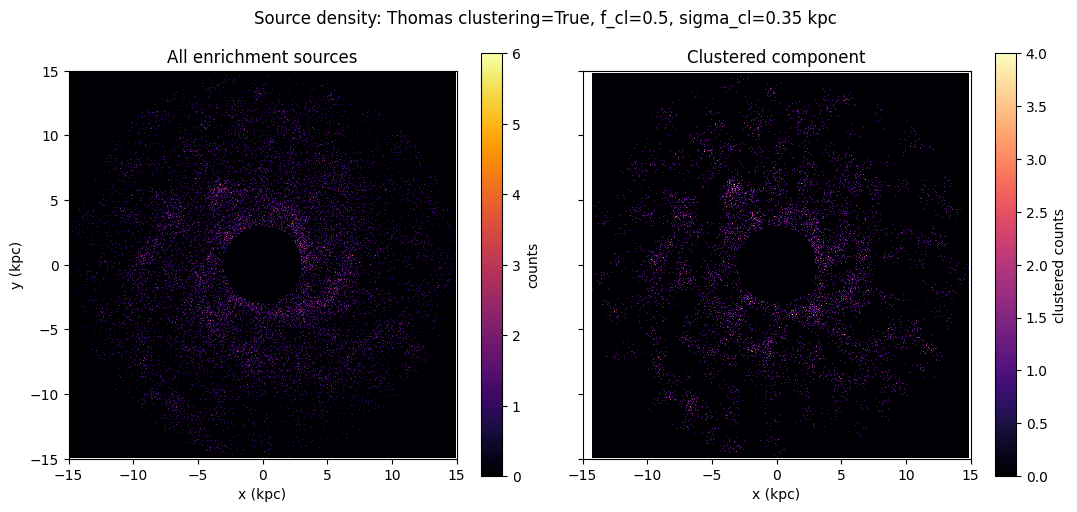

In [3]:
# %% Block 3: Generating synthetic galaxies (inhomogeneous Poisson + clustered sources + Gaussian diffusion)
# --- Expected number of events ---
Nr, Nphi = 200, 400
varpi_edges = np.linspace(R_in, R_out, Nr+1)
phi_edges = np.linspace(0, 2*np.pi, Nphi+1)
varpi_c = 0.5*(varpi_edges[:-1] + varpi_edges[1:])
phi_c = 0.5*(phi_edges[:-1] + phi_edges[1:])
dvarpi = np.diff(varpi_edges)
dphi = 2*np.pi / Nphi
area_cells = (varpi_c * dvarpi)[:, None] * dphi
lam_grid = np.array([[lambda_rate(varpi_c[ir], phi_c[ip]) for ip in range(Nphi)] for ir in range(Nr)])
expected_total = np.sum(lam_grid * area_cells) * t_star
lam_max = np.max(lam_grid)

# --- Computational grid for abundance fields ---
grid_x = np.arange(-grid_radius, grid_radius+dx, dx)
grid_y = np.arange(-grid_radius, grid_radius+dx, dx)
X, Y = np.meshgrid(grid_x, grid_y)

def sample_spiral_positions(n_sample, rng):
    """Sample positions from the spiral-modulated mean rate in the annulus."""
    if n_sample <= 0:
        return np.empty(0), np.empty(0)

    events_varpi = np.empty(0)
    events_phi = np.empty(0)
    n_cand = max(int(3*n_sample), 1)
    while len(events_varpi) < n_sample:
        varpi_cand = np.sqrt(rng.uniform(R_in**2, R_out**2, n_cand))
        phi_cand = rng.uniform(0, 2*np.pi, n_cand)
        lam_cand = lambda_rate(varpi_cand, phi_cand)
        accept = rng.uniform(size=n_cand) < lam_cand / lam_max
        events_varpi = np.concatenate([events_varpi, varpi_cand[accept]])
        events_phi = np.concatenate([events_phi, phi_cand[accept]])
        n_cand = max(2*(n_sample - len(events_varpi)), 1)

    return events_varpi[:n_sample], events_phi[:n_sample]

def sample_clustered_positions(n_child_target, rng):
    """Sample Thomas-process child sources around spiral-modulated parent complexes."""
    if n_child_target <= 0:
        return np.empty(0), np.empty(0)

    child_x = np.empty(0)
    child_y = np.empty(0)
    mean_children = max(mean_children_per_cluster, 1.0e-6)

    while len(child_x) < n_child_target:
        deficit = n_child_target - len(child_x)
        n_parent = max(rng.poisson(deficit/mean_children), 1)
        parent_varpi, parent_phi = sample_spiral_positions(n_parent, rng)
        parent_x = parent_varpi*np.cos(parent_phi)
        parent_y = parent_varpi*np.sin(parent_phi)
        child_counts = rng.poisson(mean_children, n_parent)
        n_batch = int(np.sum(child_counts))
        if n_batch == 0:
            continue

        px = np.repeat(parent_x, child_counts)
        py = np.repeat(parent_y, child_counts)
        cx = px + rng.normal(0.0, cluster_radius, n_batch)
        cy = py + rng.normal(0.0, cluster_radius, n_batch)
        cr = np.hypot(cx, cy)
        keep = (cr >= R_in) & (cr <= R_out)
        child_x = np.concatenate([child_x, cx[keep]])
        child_y = np.concatenate([child_y, cy[keep]])

    return child_x[:n_child_target], child_y[:n_child_target]

def generate_synthetic_galaxy(rng, return_events=False):
    """Generate one enrichment realization with optional Thomas source clustering."""
    n_total = rng.poisson(expected_total)
    use_clustering = enable_source_clustering and cluster_fraction > 0
    if use_clustering:
        n_clustered = rng.binomial(n_total, np.clip(cluster_fraction, 0.0, 1.0))
    else:
        n_clustered = 0
    n_poisson = n_total - n_clustered

    poisson_varpi, poisson_phi = sample_spiral_positions(n_poisson, rng)
    poisson_x = poisson_varpi*np.cos(poisson_phi)
    poisson_y = poisson_varpi*np.sin(poisson_phi)
    cluster_x, cluster_y = sample_clustered_positions(n_clustered, rng)

    event_x = np.concatenate([poisson_x, cluster_x])
    event_y = np.concatenate([poisson_y, cluster_y])
    event_is_clustered = np.concatenate([
        np.zeros(len(poisson_x), dtype=bool),
        np.ones(len(cluster_x), dtype=bool),
    ])

    if len(event_x) > 0:
        order = rng.permutation(len(event_x))
        event_x = event_x[order]
        event_y = event_y[order]
        event_is_clustered = event_is_clustered[order]
    ages = rng.uniform(0, t_star, len(event_x))

    Z = np.zeros_like(X)
    for i in range(len(event_x)):
        Bs = 0.5*x0**2 + kappa * ages[i]
        cutoff = 5.0 * np.sqrt(2*Bs)
        dist2 = (X - event_x[i])**2 + (Y - event_y[i])**2
        mask = dist2 < cutoff**2
        Z[mask] += Y_val * np.exp(-dist2[mask]/(4*Bs)) / (4*np.pi*Bs)

    if return_events:
        return Z, len(event_x), event_x, event_y, event_is_clustered
    return Z, len(event_x)

# Generate one displayed realization. Additional independent realizations are
# generated below when estimating correlation-function error bands.
Z, N_events, event_x, event_y, event_is_clustered = generate_synthetic_galaxy(rng, return_events=True)
print(
    f"Expected number of events: {expected_total:.0f}, realization 1: {N_events} "
    f"({np.sum(event_is_clustered)} clustered)"
)

# Visualisation of event distribution for the displayed realization.
bins = 500
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)
h0 = axes[0].hist2d(event_x, event_y, bins=bins, cmap='inferno')
plt.colorbar(h0[3], ax=axes[0], label='counts')
axes[0].set_title('All enrichment sources')
if np.any(event_is_clustered):
    h1 = axes[1].hist2d(event_x[event_is_clustered], event_y[event_is_clustered], bins=bins, cmap='magma')
    plt.colorbar(h1[3], ax=axes[1], label='clustered counts')
else:
    axes[1].text(0.5, 0.5, 'clustering disabled', transform=axes[1].transAxes,
                 ha='center', va='center')
axes[1].set_title('Clustered component')
for ax in axes:
    ax.set_xlim(-R_out, R_out)
    ax.set_ylim(-R_out, R_out)
    ax.set_aspect('equal')
    ax.set_xlabel('x (kpc)')
axes[0].set_ylabel('y (kpc)')
fig.suptitle(
    f'Source density: Thomas clustering={enable_source_clustering}, '
    f'f_cl={cluster_fraction}, sigma_cl={cluster_radius} kpc'
)
plt.tight_layout()
plt.show()


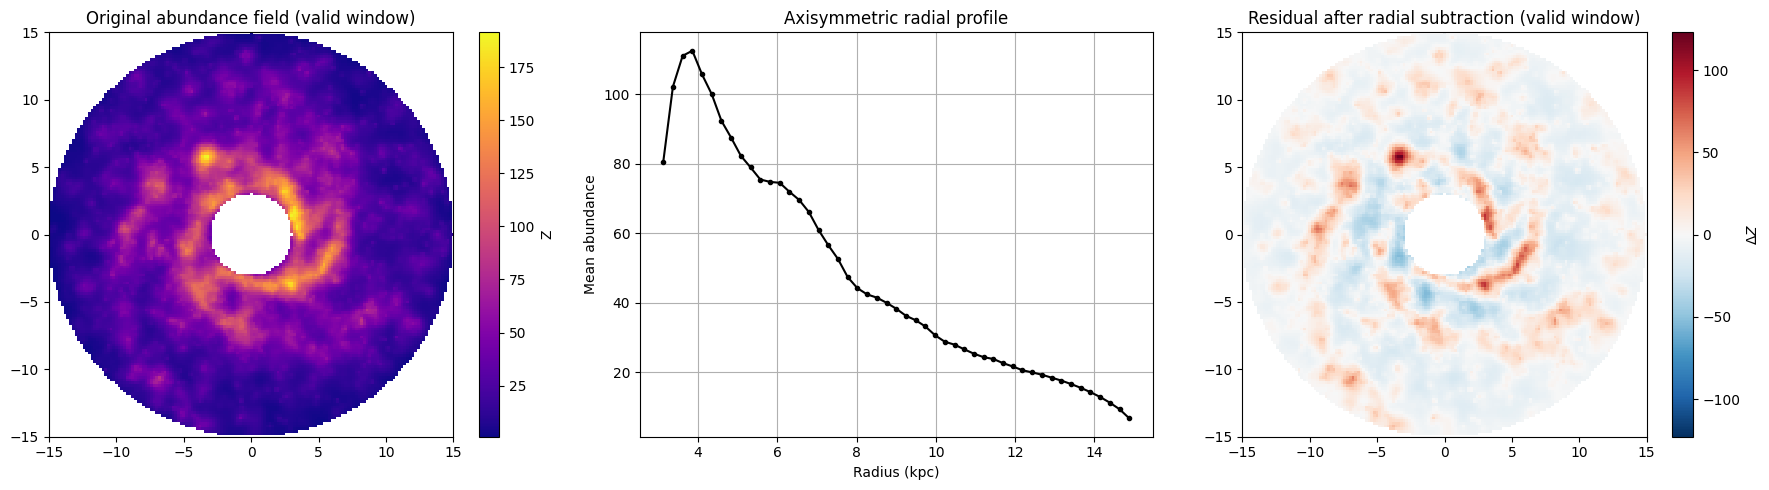

In [4]:
# %% Block 4: Subtraction of the radial gradient
R_grid = np.sqrt(X**2 + Y**2)
disk_mask = (R_grid >= R_in) & (R_grid <= R_out)
# A slightly eroded mask is used for continuous interpolation-based
# correlation measurements, so bilinear interpolation stencils do not mix in
# pixels from the excavated inner hole or exterior of the disc.
window_margin = np.sqrt(2.0) * dx
analysis_R_in = R_in + window_margin
analysis_R_out = R_out - window_margin
R_bins = np.linspace(R_in, R_out, 50)
R_c = 0.5 * (R_bins[:-1] + R_bins[1:])

def subtract_radial_background(Z, make_plot=False):
    """Subtract the axisymmetric radial profile inside the valid annulus."""
    Z_rad = np.array([
        np.nanmean(np.where((R_grid >= rl) & (R_grid < rh) & disk_mask, Z, np.nan))
        for rl, rh in zip(R_bins[:-1], R_bins[1:])
    ])
    f_mean = interp1d(R_c, Z_rad, kind='linear',
                      bounds_error=False, fill_value=(Z_rad[0], Z_rad[-1]))
    Z_bg = np.full_like(Z, np.nan, dtype=float)
    Z_bg[disk_mask] = f_mean(R_grid[disk_mask])

    Z_res = np.full_like(Z, np.nan, dtype=float)
    Z_res[disk_mask] = Z[disk_mask] - Z_bg[disk_mask]
    Z_plot = np.where(disk_mask, Z, np.nan)
    Z_res_plot = np.where(disk_mask, Z_res, np.nan)
    Z_res_interp = np.where(np.isfinite(Z_res), Z_res, 0.0)

    if make_plot:
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        im1 = axes[0].pcolormesh(X, Y, Z_plot, cmap='plasma', shading='auto')
        plt.colorbar(im1, ax=axes[0], label='Z')
        axes[0].set_title('Original abundance field (valid window)')
        axes[0].set_xlim(-R_out, R_out)
        axes[0].set_ylim(-R_out, R_out)
        axes[0].set_aspect('equal')

        axes[1].plot(R_c, Z_rad, 'ko-', markersize=3)
        axes[1].set_xlabel('Radius (kpc)')
        axes[1].set_ylabel('Mean abundance')
        axes[1].set_title('Axisymmetric radial profile')
        axes[1].grid(True)

        vmax = np.nanmax(np.abs(Z_res_plot))
        im2 = axes[2].pcolormesh(X, Y, Z_res_plot, cmap='RdBu_r', shading='auto',
                                 vmin=-vmax, vmax=vmax)
        plt.colorbar(im2, ax=axes[2], label=r'$\Delta Z$')
        axes[2].set_title('Residual after radial subtraction (valid window)')
        axes[2].set_xlim(-R_out, R_out)
        axes[2].set_ylim(-R_out, R_out)
        axes[2].set_aspect('equal')

        plt.tight_layout()
        plt.show()

    return {
        'Z_rad': Z_rad,
        'Z_bg': Z_bg,
        'Z_res': Z_res,
        'Z_plot': Z_plot,
        'Z_res_plot': Z_res_plot,
        'Z_res_interp': Z_res_interp,
    }

first_residual = subtract_radial_background(Z, make_plot=True)
Z_rad = first_residual['Z_rad']
Z_bg = first_residual['Z_bg']
Z_res = first_residual['Z_res']
Z_plot = first_residual['Z_plot']
Z_res_plot = first_residual['Z_res_plot']
Z_res_interp = first_residual['Z_res_interp']


In [5]:
# %% Section 5: The two-point correlation function $\xi_2(\varpi_m, r)$ in the simulation
# Test midpoint radii are kept inside the eroded observing window.
radii_test = np.round(np.linspace(analysis_R_in + 0.5, analysis_R_out - 0.5, 6), 2)

# Pair separations are restricted to the physical outer radius of the disc.
max_pair_separation = R_out
r_bins = np.linspace(0.1, max_pair_separation, 30)
r_centers = 0.5*(r_bins[:-1] + r_bins[1:])
num_pairs = 50000

def measure_xi2_from_residual(Z_res_interp, rng):
    interp_Z = RegularGridInterpolator((grid_x, grid_y), Z_res_interp.T,
                                       bounds_error=False, fill_value=np.nan)
    corr = {}
    for varpi_m in radii_test:
        mid_phi = rng.uniform(0, 2*np.pi, num_pairs)
        sep_psi = rng.uniform(0, 2*np.pi, num_pairs)
        sep_r = rng.uniform(r_bins[0], r_bins[-1], num_pairs)
        mid_x = varpi_m * np.cos(mid_phi)
        mid_y = varpi_m * np.sin(mid_phi)
        dx_pair = 0.5*sep_r*np.cos(sep_psi)
        dy_pair = 0.5*sep_r*np.sin(sep_psi)
        xm, ym = mid_x - dx_pair, mid_y - dy_pair
        xp, yp = mid_x + dx_pair, mid_y + dy_pair
        rm = np.hypot(xm,ym)
        rp = np.hypot(xp,yp)
        valid = (sep_r <= max_pair_separation) & (rm>=analysis_R_in) & (rm<=analysis_R_out) & (rp>=analysis_R_in) & (rp<=analysis_R_out)
        Zm = interp_Z(np.column_stack((xm[valid], ym[valid])))
        Zp = interp_Z(np.column_stack((xp[valid], yp[valid])))
        r_valid = sep_r[valid]
        corr_vals = np.full(len(r_centers), np.nan)
        for i, (rl, rh) in enumerate(zip(r_bins[:-1], r_bins[1:])):
            mask = (r_valid>=rl) & (r_valid<rh) & np.isfinite(Zm) & np.isfinite(Zp)
            if np.sum(mask) > 10:
                # The radial profile has already been subtracted. Do not subtract
                # a fresh mean in each separation bin, because that would remove
                # part of the fixed spiral mean-field covariance C_M.
                z1 = Zm[mask]
                z2 = Zp[mask]
                denom = np.sqrt(np.mean(z1**2) * np.mean(z2**2))
                corr_vals[i] = np.mean(z1*z2) / denom if denom > 0 else np.nan
        corr[varpi_m] = corr_vals
    return corr

# Collect independent numerical realizations for error bands.
residual_fields = [Z_res_interp]
xi2_realizations = [measure_xi2_from_residual(Z_res_interp, rng)]
for ireal in range(1, n_realizations):
    Z_i, N_i = generate_synthetic_galaxy(rng, return_events=False)
    res_i = subtract_radial_background(Z_i, make_plot=False)
    residual_fields.append(res_i['Z_res_interp'])
    xi2_realizations.append(measure_xi2_from_residual(res_i['Z_res_interp'], rng))
    print(f"Completed realization {ireal+1}/{n_realizations}: N_events={N_i}")

sim_corr_mean = {
    varpi_m: np.nanmean(np.vstack([real[varpi_m] for real in xi2_realizations]), axis=0)
    for varpi_m in radii_test
}
sim_corr_std = {
    varpi_m: np.nanstd(np.vstack([real[varpi_m] for real in xi2_realizations]), axis=0, ddof=1)
    if n_realizations > 1 else np.zeros_like(sim_corr_mean[varpi_m])
    for varpi_m in radii_test
}


Completed realization 2/10: N_events=25199


Completed realization 3/10: N_events=24900


Completed realization 4/10: N_events=24864


Completed realization 5/10: N_events=24659


Completed realization 6/10: N_events=25213


Completed realization 7/10: N_events=24963


Completed realization 8/10: N_events=24747


Completed realization 9/10: N_events=24975


Completed realization 10/10: N_events=24585


In [6]:
# %% Block 6: KTZ prediction
from functools import lru_cache

p0_val = x0**2
p_ast_val = x0**2 + 2*kappa*t_star
component_order = ['CP0', 'CPN', 'CM', 'CNP']
component_colors = {
    'CP0': '#7fc97f',
    'CPN': '#ffff99',
    'CM': '#fdc086',
    'CNP': '#beaed4',
}


component_labels = {
    'CP0': r'$C_{\rm P,0}$',
    'CPN': r'$C_{\rm P,N}$',
    'CM': r'$C_{\rm M}$',
    'CNP': r'$C_{\rm NP}$',
}

@lru_cache(maxsize=None)
def I0(r):
    if r==0: return 0.5*np.log(p_ast_val/p0_val)
    # I0 = 1/2 [E1(r^2/4p_ast) - E1(r^2/4p0)] > 0.
    return 0.5*(exp1(r**2/(4*p_ast_val)) - exp1(r**2/(4*p0_val)))

@lru_cache(maxsize=None)
def InP(r, Qn):
    f = lambda p: 0.5/p * np.exp(-r**2/(4*p) - Qn**2*p/4)
    I, _ = quad(f, p0_val, p_ast_val, limit=100)
    return I

@lru_cache(maxsize=None)
def Tn(Qn):
    if Qn==0: return t_star
    return np.exp(-0.5*x0**2*Qn**2) * (1-np.exp(-kappa*t_star*Qn**2)) / (kappa*Qn**2)

# Thomas-process source clustering adds a non-Poisson covariance term.  We model
# the source pair correlation as Gaussian with correlation length
# l_src = sqrt(2)*cluster_radius, which corresponds to child offsets drawn with
# one-dimensional dispersion cluster_radius around each parent complex.
_cluster_quad_x, _cluster_quad_w = np.polynomial.legendre.leggauss(cluster_theory_nodes)
_cluster_t_nodes = 0.5*t_star*(_cluster_quad_x + 1.0)
_cluster_t_weights = 0.5*t_star*_cluster_quad_w
_cluster_p_nodes = x0**2 + 2*kappa*_cluster_t_nodes
_cluster_source_corr_len2 = 2.0*cluster_radius**2

@lru_cache(maxsize=None)
def I_cluster_np(r):
    if (not enable_source_clustering) or cluster_fraction <= 0 or cluster_radius <= 0:
        return 0.0
    denom = _cluster_source_corr_len2 + _cluster_p_nodes[:, None] + _cluster_p_nodes[None, :]
    weight = _cluster_t_weights[:, None] * _cluster_t_weights[None, :]
    integrand = (_cluster_source_corr_len2 / denom) * np.exp(-r**2/(2.0*denom))
    return float(np.sum(weight * integrand))

def CNP_prefactor(varpi_m):
    if (not enable_source_clustering) or cluster_fraction <= 0 or cluster_radius <= 0:
        return 0.0
    lam_local = lambda0_0 * np.exp(-varpi_m/h_R)
    lam_clustered = max(cluster_fraction * lam_local, 1.0e-30)
    # Parent complexes are sampled over the full age window.  The Thomas-process
    # pair-correlation amplitude therefore uses the integrated clustered surface
    # density Sigma_cl = lambda_clustered*t_star, not the instantaneous rate.
    sigma_clustered = lam_clustered * t_star
    xi0 = mean_children_per_cluster / (4*np.pi*sigma_clustered*cluster_radius**2)
    # The total source covariance scales as lambda_total * cluster_fraction^2 * xi_src.
    return 4*np.pi*kappa*lam_local*(cluster_fraction**2)*xi0

def A_P_factor(varpi_m):
    r"""Common physical covariance scale $A_{\rm P}(\varpi)$."""
    lam_local = lambda0_0 * np.exp(-varpi_m/h_R)
    return (Y_val**2) * lam_local / (4*np.pi*kappa)

def source_harmonic_damping(Qn):
    """Damping of the source-rate spiral harmonic caused by clustered child offsets."""
    if (not enable_source_clustering) or cluster_fraction <= 0 or cluster_radius <= 0:
        return 1.0
    f_cl = np.clip(cluster_fraction, 0.0, 1.0)
    child_damping = np.exp(-0.5*(Qn*cluster_radius)**2)
    return (1.0 - f_cl) + f_cl*child_damping

def local_cov_component_parts(varpi_m, phi_m, r, psi):
    Theta_m = spiral_phase(varpi_m, phi_m)
    Q_base = k_perp(varpi_m)
    dPhi = (m_arms/np.tan(pitch_rad))/varpi_m
    grad_x = dPhi*np.cos(phi_m) + (m_arms/varpi_m)*np.sin(phi_m)
    grad_y = dPhi*np.sin(phi_m) - (m_arms/varpi_m)*np.cos(phi_m)
    grad = np.array([grad_x, grad_y])
    r_vec = r*np.array([np.cos(psi), np.sin(psi)])

    # Linearized endpoint phases: Theta_+ - Theta_- = grad(Theta) dot r_vec.
    dot = np.dot(grad, r_vec)
    Theta_minus = Theta_m - 0.5*dot
    Theta_plus  = Theta_m + 0.5*dot

    lam_local = lambda0_0 * np.exp(-varpi_m/h_R)
    R_val = 4*np.pi*kappa*lam_local*eta**2

    CPN_num = 0.0
    CPN_var_m = 0.0
    CPN_var_p = 0.0
    mean_minus = 0.0
    mean_plus = 0.0

    for n, g, alpha in zip(harmonic_n, harmonic_g, harmonic_alpha):
        Qn = n * Q_base
        damping = source_harmonic_damping(Qn)
        S_m = g*damping*np.cos(n*Theta_m + alpha)
        S_mi = g*damping*np.cos(n*Theta_minus + alpha)
        S_pl = g*damping*np.cos(n*Theta_plus + alpha)

        CPN_num += InP(r, Qn)*S_m
        CPN_var_m += InP(0, Qn)*S_mi
        CPN_var_p += InP(0, Qn)*S_pl

        Tn_val = Tn(Qn)
        mean_minus += Tn_val*S_mi
        mean_plus += Tn_val*S_pl

    # Numerator covariance pieces, after extracting the common A_P factor.
    nums = {
        'CP0': I0(r),
        'CPN': eta*CPN_num,
        'CM': R_val * mean_minus * mean_plus,
        'CNP': CNP_prefactor(varpi_m) * I_cluster_np(r),
    }
    # Endpoint variance pieces. CNP uses the same local clustering approximation.
    vars_m_parts = {
        'CP0': I0(0),
        'CPN': eta*CPN_var_m,
        'CM': R_val*mean_minus**2,
        'CNP': CNP_prefactor(varpi_m) * I_cluster_np(0.0),
    }
    vars_p_parts = {
        'CP0': I0(0),
        'CPN': eta*CPN_var_p,
        'CM': R_val*mean_plus**2,
        'CNP': CNP_prefactor(varpi_m) * I_cluster_np(0.0),
    }
    return nums, vars_m_parts, vars_p_parts

def endpoint_window_ok(varpi_m, phi_m, r, psi):
    if r < 0 or r > max_pair_separation:
        return False
    mid_x = varpi_m*np.cos(phi_m)
    mid_y = varpi_m*np.sin(phi_m)
    hx = 0.5*r*np.cos(psi)
    hy = 0.5*r*np.sin(psi)
    rm = np.hypot(mid_x - hx, mid_y - hy)
    rp = np.hypot(mid_x + hx, mid_y + hy)
    return (analysis_R_in <= rm <= analysis_R_out) and (analysis_R_in <= rp <= analysis_R_out)

def _component_average_from_samples(sample_parts, sample_weights=None):
    if not sample_parts:
        return {name: np.nan for name in component_order}

    if sample_weights is None:
        sample_weights = np.ones(len(sample_parts), dtype=float)
    else:
        sample_weights = np.asarray(sample_weights, dtype=float)
        if len(sample_weights) != len(sample_parts):
            raise ValueError("sample_weights must match sample_parts")

    nums_by_component = {name: [] for name in component_order}
    vars_m_total, vars_p_total = [], []
    local_denoms = []
    for weight, (nums, vars_m_parts, vars_p_parts) in zip(sample_weights, sample_parts):
        if (not np.isfinite(weight)) or weight <= 0:
            continue
        var_m = sum(vars_m_parts.values())
        var_p = sum(vars_p_parts.values())
        if var_m <= 0 or var_p <= 0:
            continue
        # The local expressions have the common scale A_P factored out.
        # For fixed-varpi xi2 this cancels, but full-window xi3 must average the
        # physical covariance and variance before normalization.
        weighted_var_m = weight * var_m
        weighted_var_p = weight * var_p
        for name in component_order:
            nums_by_component[name].append(weight * nums[name])
        vars_m_total.append(weighted_var_m)
        vars_p_total.append(weighted_var_p)
        local_denoms.append(np.sqrt(weighted_var_m*weighted_var_p))

    if not vars_m_total:
        return {name: np.nan for name in component_order}

    denom = np.sqrt(np.mean(vars_m_total)*np.mean(vars_p_total))
    return {
        name: np.mean(nums_by_component[name]) / denom
        for name in component_order
    }

def xi2_KTZ_components(varpi_m, r, Nphi=40, Npsi=40):
    phi_arr = np.linspace(0,2*np.pi,Nphi,endpoint=False)
    psi_arr = np.linspace(0,2*np.pi,Npsi,endpoint=False)
    sample_parts = []
    for phi in phi_arr:
        for psi in psi_arr:
            if endpoint_window_ok(varpi_m, phi, r, psi):
                sample_parts.append(local_cov_component_parts(varpi_m, phi, r, psi))
    return _component_average_from_samples(sample_parts)

def components_to_arrays(component_list):
    return {name: np.array([comp[name] for comp in component_list]) for name in component_order}


def plot_theory_component_stack(
    ax, r_plot, comp_plot, alpha=0.42, labels=None
):
    if labels is None:
        labels = component_labels
    cumulative = np.zeros_like(r_plot, dtype=float)
    handles = []
    for name in component_order:
        vals = comp_plot[name]
        next_cumulative = cumulative + vals
        handle = ax.fill_between(
            r_plot, cumulative, next_cumulative,
            color=component_colors[name], alpha=alpha, linewidth=0,
            label=labels[name], zorder=1,
        )
        handles.append(handle)
        cumulative = next_cumulative
    return handles

wkb_components = {}
for varpi_m in radii_test:
    comp_list = [xi2_KTZ_components(varpi_m, r) for r in r_centers]
    wkb_components[varpi_m] = components_to_arrays(comp_list)

# Full azimuthal averaging in the circular annulus cancels every linear
# harmonic at the covariance level. The residual is quadrature roundoff.
xi2_CPN_max = max(
    np.nanmax(np.abs(wkb_components[varpi_m]['CPN']))
    for varpi_m in radii_test
)
assert xi2_CPN_max < 1.0e-12


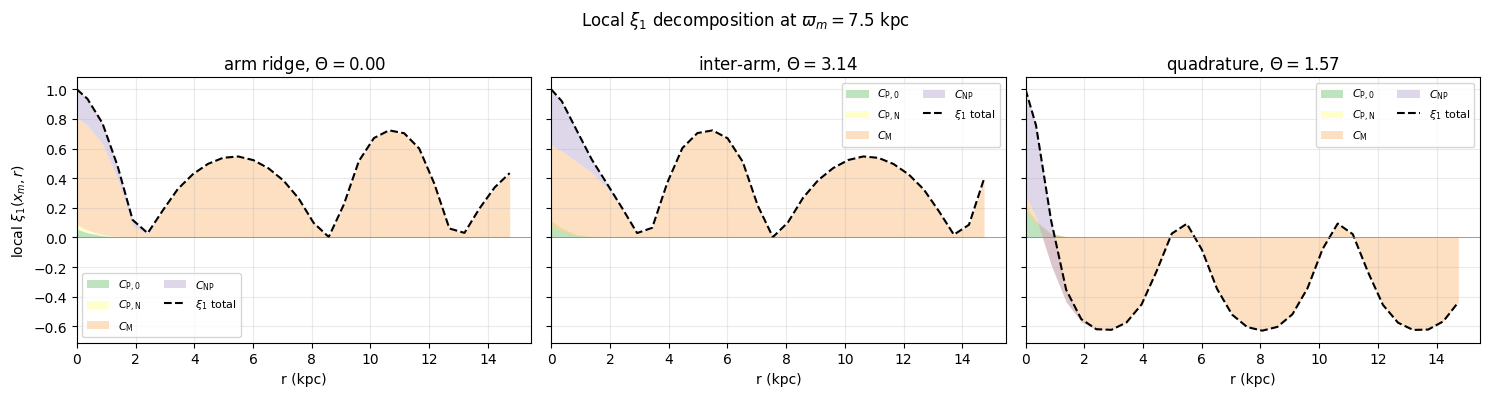

In [7]:
# %% Block 6b: Local xi1 diagnostic before annular averaging
# This diagnostic fixes the midpoint radius and spiral phase, so the signed CPN
# contribution is not averaged away over a full annulus. It is useful for
# checking the local theory before comparing xi2/xi3.

xi1_varpi_test = 7.5
xi1_phase_cases = {
    'arm ridge': 0.0,
    'inter-arm': np.pi,
    'quadrature': 0.5*np.pi,
}
xi1_psi_local = 0.0  # separation along the local arm-normal direction
xi1_r = r_centers

def phi_for_theta(varpi, theta_target):
    """Return a disc azimuth whose midpoint has the requested spiral phase."""
    Phi = (m_arms / np.tan(pitch_rad)) * np.log(varpi / R_in)
    return (Phi + Theta0 - theta_target) / m_arms

def xi1_components(varpi, theta_target, r, psi_local=0.0):
    phi_m = phi_for_theta(varpi, theta_target)
    dPhi = (m_arms/np.tan(pitch_rad))/varpi
    grad_x = dPhi*np.cos(phi_m) + (m_arms/varpi)*np.sin(phi_m)
    grad_y = dPhi*np.sin(phi_m) - (m_arms/varpi)*np.cos(phi_m)
    grad_angle = np.arctan2(grad_y, grad_x)
    psi_global = grad_angle + psi_local
    nums, var_m_parts, var_p_parts = local_cov_component_parts(varpi, phi_m, r, psi_global)
    var_m = sum(var_m_parts.values())
    var_p = sum(var_p_parts.values())
    if var_m <= 0 or var_p <= 0:
        return {name: np.nan for name in component_order}
    denom = np.sqrt(var_m*var_p)
    return {name: nums[name]/denom for name in component_order}

fig, axes = plt.subplots(1, len(xi1_phase_cases), figsize=(15, 4), sharey=True)
if len(xi1_phase_cases) == 1:
    axes = [axes]

for ax, (label, theta_target) in zip(axes, xi1_phase_cases.items()):
    comp_list = [xi1_components(xi1_varpi_test, theta_target, r, xi1_psi_local) for r in xi1_r]
    comp_arrays = components_to_arrays(comp_list)
    comp0 = xi1_components(xi1_varpi_test, theta_target, 0.0, xi1_psi_local)
    comp_plot = {
        name: np.concatenate([[comp0[name]], comp_arrays[name]])
        for name in component_order
    }
    r_plot = np.concatenate([[0.0], xi1_r])
    xi1_total = sum(comp_plot[name] for name in component_order)

    plot_theory_component_stack(ax, r_plot, comp_plot, alpha=0.5)
    ax.plot(r_plot, xi1_total, 'k--', lw=1.5, label=r'$\xi_1$ total')
    ax.axhline(0, color='grey', lw=0.5)
    ax.set_title(fr'{label}, $\Theta={theta_target:.2f}$')
    ax.set_xlabel('r (kpc)')
    ax.set_xlim(left=0)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8, ncol=2)

axes[0].set_ylabel(r'local $\xi_1(x_m, r)$')
fig.suptitle(fr'Local $\xi_1$ decomposition at $\varpi_m={xi1_varpi_test}$ kpc')
plt.tight_layout()
plt.show()


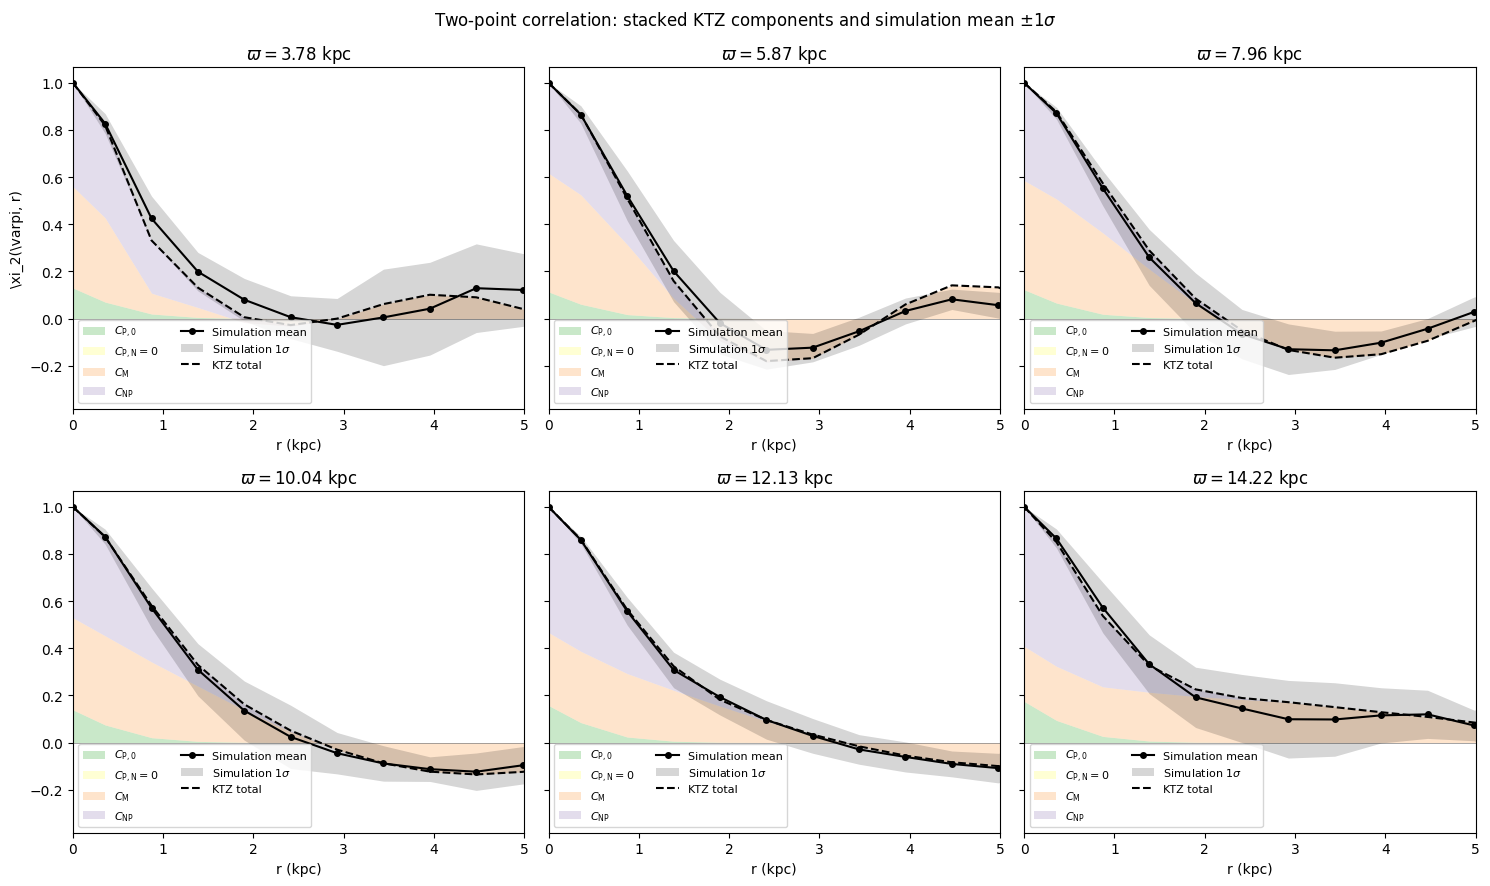

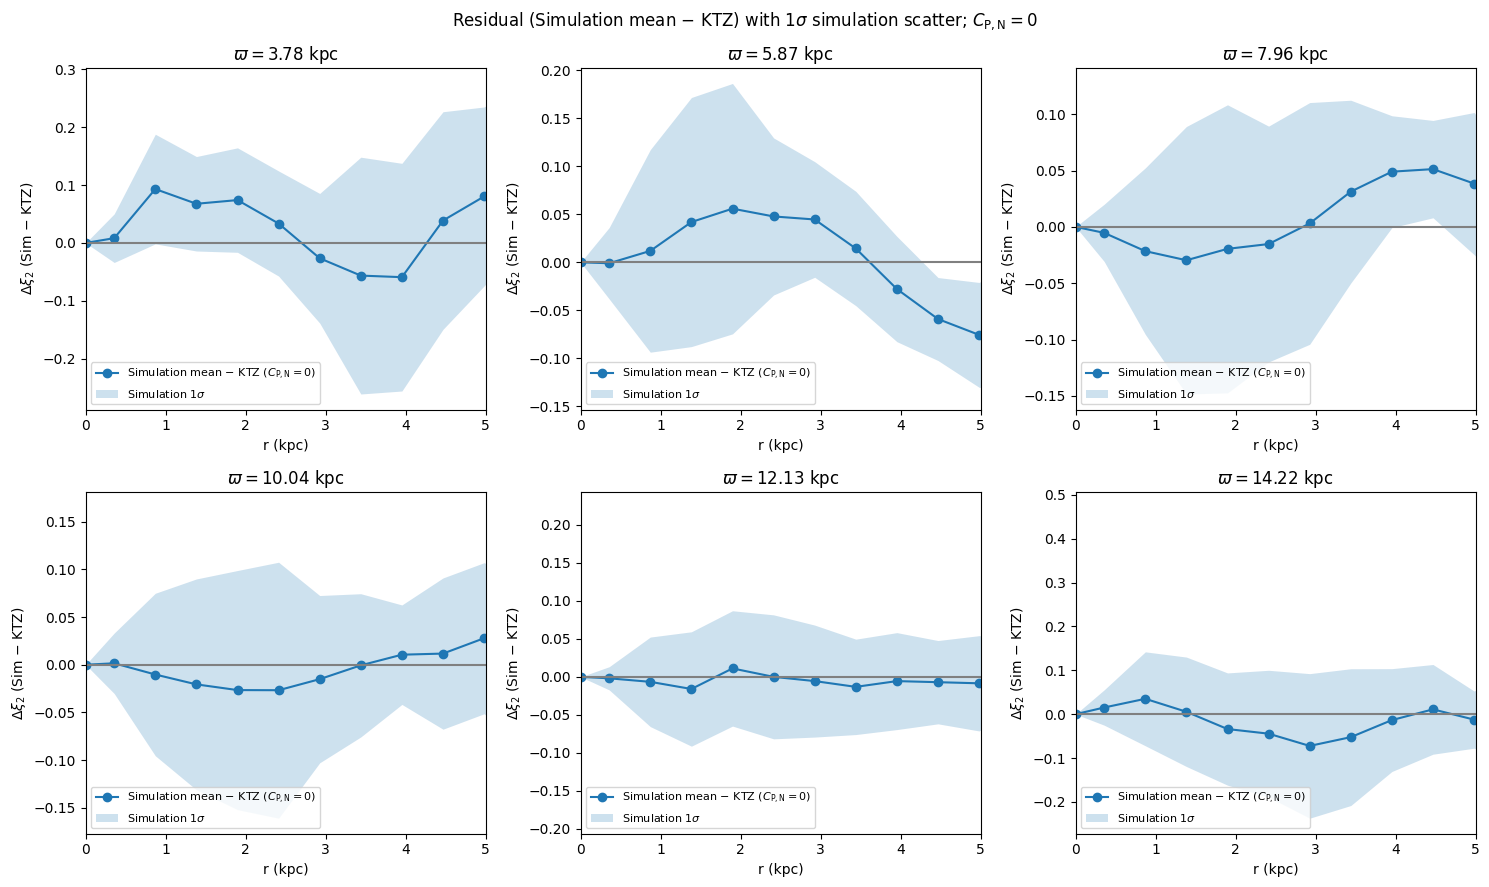

In [8]:
# %% Block 7a: Comparison of correlation functions
correlation_plot_rmax = 5.0
annular_component_labels = component_labels.copy()
annular_component_labels['CPN'] = r'$C_{\rm P,N}=0$'

fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharey=True)
axes = axes.flatten()

for ax, varpi_m in zip(axes, radii_test):
    r_plot = np.concatenate([[0.0], r_centers])
    sim_mean = np.concatenate([[1.0], sim_corr_mean[varpi_m]])
    sim_std = np.concatenate([[0.0], sim_corr_std[varpi_m]])
    comp0 = xi2_KTZ_components(varpi_m, 0.0)
    comp_plot = {
        name: np.concatenate([[comp0[name]], wkb_components[varpi_m][name]])
        for name in component_order
    }
    wkb_plot = sum(comp_plot[name] for name in component_order)

    plot_theory_component_stack(
        ax, r_plot, comp_plot, labels=annular_component_labels
    )
    ax.plot(r_plot, sim_mean, 'o-', color='black', ms=4, label='Simulation mean', zorder=4)
    ax.fill_between(r_plot, sim_mean-sim_std, sim_mean+sim_std,
                    color='black', alpha=0.16, linewidth=0,
                    label=r'Simulation $1\sigma$', zorder=3)
    ax.plot(r_plot, wkb_plot, 'k--', lw=1.5, label='KTZ total', zorder=5)
    ax.axhline(0, color='grey', lw=0.5)
    ax.set_title(fr'$\varpi = {varpi_m}$ kpc')
    ax.set_xlabel('r (kpc)')
    ax.set_xlim(0, correlation_plot_rmax)
    ax.legend(loc='lower left', fontsize=8, ncol=2)

axes[0].set_ylabel(r'\xi_2(\varpi, r)')
fig.suptitle(fr'Two-point correlation: stacked KTZ components and simulation mean $\pm 1\sigma$')
plt.tight_layout()
plt.show()

# %% Block 7b: Residual
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, varpi_m in zip(axes, radii_test):
    r_plot = np.concatenate([[0.0], r_centers])
    comp0 = xi2_KTZ_components(varpi_m, 0.0)
    wkb_plot = sum(
        np.concatenate([[comp0[name]], wkb_components[varpi_m][name]])
        for name in component_order
    )
    # At zero separation both simulation and theory are normalized to xi=1,
    # so the residual must be exactly zero.
    diff = np.concatenate([[1.0], sim_corr_mean[varpi_m]]) - wkb_plot
    diff[0] = 0.0
    sim_std = np.concatenate([[0.0], sim_corr_std[varpi_m]])

    ax.plot(
        r_plot, diff, 'o-',
        label=r'Simulation mean $-$ KTZ ($C_{\rm P,N}=0$)'
    )
    ax.fill_between(
        r_plot, diff-sim_std, diff+sim_std,
        color='C0', alpha=0.22, linewidth=0,
        label=r'Simulation $1\sigma$'
    )
    ax.axhline(0, color='grey')
    ax.set_title(fr'$\varpi = {varpi_m}$ kpc')
    ax.set_xlabel('r (kpc)')
    ax.set_ylabel(r'$\Delta\xi_2$ (Sim $-$ KTZ)')
    ax.set_xlim(0, correlation_plot_rmax)
    ax.legend(loc='lower left', fontsize=8)

fig.suptitle(
    r'Residual (Simulation mean $-$ KTZ) with $1\sigma$ simulation scatter; '
    r'$C_{\rm P,N}=0$'
)
plt.tight_layout()
plt.show()


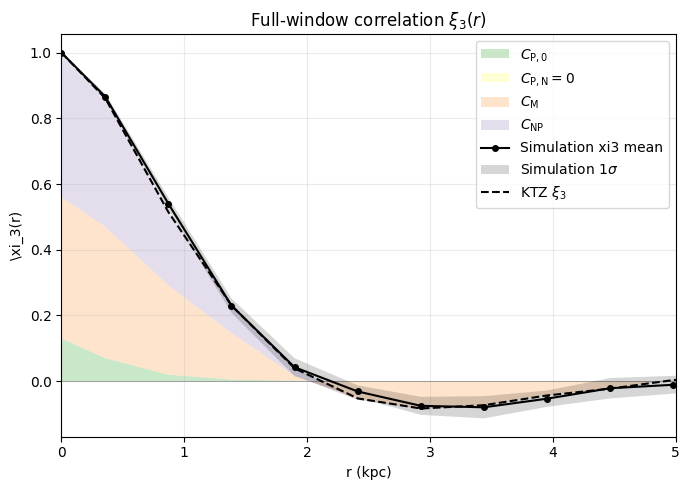

In [9]:
# %% Block 8: xi3(r) over the full observing window
# xi3 averages over all valid midpoint radii and separation directions.
# The simulation and KTZ curves both use the pair-product estimator.
# Because xi3 mixes radii, the KTZ average keeps the physical
# $A_{\rm P}(\varpi)$ covariance weight before normalization.

num_pairs_xi3 = 150000

def measure_xi3_from_residual(Z_res_interp, rng):
    interp_Z = RegularGridInterpolator((grid_x, grid_y), Z_res_interp.T,
                                       bounds_error=False, fill_value=np.nan)
    mid_R = np.sqrt(rng.uniform(analysis_R_in**2, analysis_R_out**2, num_pairs_xi3))
    mid_phi = rng.uniform(0, 2*np.pi, num_pairs_xi3)
    sep_psi = rng.uniform(0, 2*np.pi, num_pairs_xi3)
    sep_r = rng.uniform(r_bins[0], r_bins[-1], num_pairs_xi3)

    mid_x = mid_R*np.cos(mid_phi)
    mid_y = mid_R*np.sin(mid_phi)
    hx = 0.5*sep_r*np.cos(sep_psi)
    hy = 0.5*sep_r*np.sin(sep_psi)
    xm, ym = mid_x - hx, mid_y - hy
    xp, yp = mid_x + hx, mid_y + hy
    valid = (
        (sep_r <= max_pair_separation) &
        (np.hypot(xm,ym) >= analysis_R_in) & (np.hypot(xm,ym) <= analysis_R_out) &
        (np.hypot(xp,yp) >= analysis_R_in) & (np.hypot(xp,yp) <= analysis_R_out)
    )
    Zm = interp_Z(np.column_stack((xm[valid], ym[valid])))
    Zp = interp_Z(np.column_stack((xp[valid], yp[valid])))
    r_valid = sep_r[valid]

    xi3_vals = np.full(len(r_centers), np.nan)
    for i, (rl, rh) in enumerate(zip(r_bins[:-1], r_bins[1:])):
        mask = (r_valid >= rl) & (r_valid < rh) & np.isfinite(Zm) & np.isfinite(Zp)
        if np.sum(mask) > 10:
            z1 = Zm[mask]
            z2 = Zp[mask]
            denom = np.sqrt(np.mean(z1**2) * np.mean(z2**2))
            xi3_vals[i] = np.mean(z1*z2) / denom if denom > 0 else np.nan
    return xi3_vals

xi3_realizations = [measure_xi3_from_residual(field, rng) for field in residual_fields]
xi3_stack = np.vstack(xi3_realizations)
xi3_sim_mean = np.nanmean(xi3_stack, axis=0)
xi3_sim_std = np.nanstd(xi3_stack, axis=0, ddof=1) if n_realizations > 1 else np.zeros_like(xi3_sim_mean)
def xi3_KTZ_components(r, Nvarpi=30, Nphi=20, Npsi=20):
    # Equal spacing in R^2 gives equal-area annular samples for the midpoint.
    rho2_edges = np.linspace(analysis_R_in**2, analysis_R_out**2, Nvarpi+1)
    varpi_arr = np.sqrt(0.5*(rho2_edges[:-1] + rho2_edges[1:]))
    phi_arr = np.linspace(0, 2*np.pi, Nphi, endpoint=False)
    psi_arr = np.linspace(0, 2*np.pi, Npsi, endpoint=False)
    sample_parts = []
    sample_weights = []
    for varpi in varpi_arr:
        weight = A_P_factor(varpi)
        for phi in phi_arr:
            for psi in psi_arr:
                if endpoint_window_ok(varpi, phi, r, psi):
                    sample_parts.append(local_cov_component_parts(varpi, phi, r, psi))
                    sample_weights.append(weight)
    return _component_average_from_samples(
        sample_parts, sample_weights=sample_weights
    )

xi3_component_list = [xi3_KTZ_components(r) for r in r_centers]
xi3_ktz_components = components_to_arrays(xi3_component_list)
xi3_CPN_max = np.nanmax(np.abs(xi3_ktz_components['CPN']))
assert xi3_CPN_max < 1.0e-12
xi3_ktz = sum(xi3_ktz_components[name] for name in component_order)

fig, ax = plt.subplots(figsize=(7, 5))
r_plot = np.concatenate([[0.0], r_centers])
sim_plot = np.concatenate([[1.0], xi3_sim_mean])
sim_std = np.concatenate([[0.0], xi3_sim_std])
ktz_plot = np.concatenate([[1.0], xi3_ktz])

xi3_comp0 = xi3_KTZ_components(0.0)
xi3_comp_plot = {
    name: np.concatenate([[xi3_comp0[name]], xi3_ktz_components[name]])
    for name in component_order
}
plot_theory_component_stack(
    ax, r_plot, xi3_comp_plot, labels=annular_component_labels
)
ktz_plot = sum(xi3_comp_plot[name] for name in component_order)

ax.plot(r_plot, sim_plot, 'o-', color='black', ms=4, label='Simulation xi3 mean', zorder=4)
ax.fill_between(r_plot, sim_plot-sim_std, sim_plot+sim_std,
                color='black', alpha=0.16, linewidth=0,
                label=r'Simulation $1\sigma$', zorder=3)
ax.plot(
    r_plot, ktz_plot, 'k--', lw=1.5,
    label=r'KTZ $\xi_3$', zorder=5
)
ax.axhline(0, color='grey', lw=0.5)
ax.set_xlabel('r (kpc)')
ax.set_ylabel(r'\xi_3(r)')
ax.set_xlim(0, correlation_plot_rmax)
ax.set_title(fr'Full-window correlation $\xi_3(r)$')
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


# Elemental cross-correlation

This section compares the KT25 zero-lag elemental correlation $\Xi_{XY}$ with its full-window non-uniform KTZ extension. The latter includes stochastic same-event yields, Thomas source clustering, and the spiral mean field. Complete azimuthal averaging gives $C_{{\rm P},N}=0$.


In [10]:
# %% Cross-correlation Block 1: Load the KT25 yield database
from pathlib import Path
import os
import sys
import astropy.units as u
from scipy.integrate import simpson
from matplotlib.colors import TwoSlopeNorm

NOTEBOOK_ROOT = Path.cwd()

LOCAL_KT25_REPO = NOTEBOOK_ROOT / 'data' / 'kt25'

default_kt25_repo = (

    LOCAL_KT25_REPO

    if (LOCAL_KT25_REPO / 'process_data.py').exists()

    else Path.home() / '.local' / 'share' / 'z_fluctuation'

)

KT25_REPO = Path(os.environ.get(

    'KT25_REPO', str(default_kt25_repo)

))

SLUG2_REPO = Path(os.environ.get(
    'SLUG2_REPO', Path.home() / '.local' / 'share' / 'slug2'
))
SLUG_STOCHASTIC_DIR = Path(os.environ.get(
    'SLUG_STOCHASTIC_DIR', KT25_REPO / 'slug_stochastic'
))
SLUG_MOMENT_FILE = SLUG_STOCHASTIC_DIR / 'kt25_slug_yield_moments.npz'

if not (KT25_REPO / 'process_data.py').exists():
    raise FileNotFoundError(f'KT25 repository not found at {KT25_REPO}')
if not (SLUG2_REPO / 'slugpy').exists():
    raise FileNotFoundError(f'slugpy not found at {SLUG2_REPO}')

for module_path in (SLUG2_REPO, KT25_REPO):
    module_path = str(module_path)
    if module_path not in sys.path:
        sys.path.insert(0, module_path)

from slugpy import read_cluster
from asplund09_abd import solar_abd
from seitenzahl13_yld import s13_yld

kt25_channels = ['snii', 'agb', 'snia']
kt25_r_process = [
    'Ru', 'Rh', 'Rd', 'Ag', 'Cd', 'In', 'Sb', 'Te', 'I', 'Xe',
    'Cs', 'La', 'Pr', 'Nd', 'Sm', 'Eu', 'Gd', 'Tb', 'Dy',
    'Ho', 'Er', 'Tm', 'Yb'
]

# This is the data-ingestion portion of process_data.py, kept unchanged in
# substance so that the channel fractions and t_50 values match KT25.
kt25_prod = {
    row['sym']: {}
    for row in solar_abd
}
slug_agb = read_cluster(str(KT25_REPO / 'slug' / 'yields_agb'))
slug_snii = read_cluster(str(KT25_REPO / 'slug' / 'yields_snii'))
kt25_time = slug_agb.time * u.yr

kt25_tmin = 40 * u.Myr
kt25_tmax = 13.7 * u.Gyr
kt25_dtd_alpha = -1.1
kt25_dtd_norm = (
    1.3e-3 * (1 + kt25_dtd_alpha)
    / (
        kt25_tmax * (kt25_tmax / kt25_tmin)**kt25_dtd_alpha
        - kt25_tmin
    )
)
kt25_nIa = kt25_dtd_norm * (
    kt25_time * (kt25_time / kt25_tmin)**kt25_dtd_alpha - kt25_tmin
) / (1 + kt25_dtd_alpha)
kt25_nIa[kt25_time < kt25_tmin] = 0

for element in kt25_prod:
    channel_yields = {
        name: np.zeros(kt25_time.size)
        for name in ['tot', 'snii', 'agb', 'snia']
    }

    for idx in np.where(slug_snii.isotope_name == element)[0]:
        channel_yields['snii'] += slug_snii.yld[:, idx]
        channel_yields['tot'] += slug_snii.yld[:, idx]

    for idx in np.where(slug_agb.isotope_name == element)[0]:
        channel_yields['agb'] += slug_agb.yld[:, idx]
        channel_yields['tot'] += slug_agb.yld[:, idx]

    for idx in np.where(np.asarray(s13_yld['sym']) == element)[0]:
        ia_yield = s13_yld['ylds']['N100'][idx] * kt25_nIa
        channel_yields['snia'] += ia_yield
        channel_yields['tot'] += ia_yield

    for name, values in channel_yields.items():
        kt25_prod[element]['yld_' + name] = values

for element in kt25_prod:
    if kt25_prod[element]['yld_tot'][-1] <= 0:
        continue

    for channel in kt25_channels:
        channel_yield = kt25_prod[element]['yld_' + channel]
        kt25_prod[element]['t50_' + channel] = float(
            kt25_time[np.argmax(
                channel_yield > 0.5 * channel_yield[-1]
            )].to(u.Gyr).value
        )

kt25_elements = [
    row['sym'] for row in solar_abd
    if 6 <= row['Z'] <= 60
    and row['sym'] not in kt25_r_process
    and kt25_prod[row['sym']]['yld_tot'][-1] > 0
]
# Mean returned mass of each element and channel per unit stellar mass formed.
# The SLUG models use cluster_mass=1, so the final cumulative yields are
# directly the first yield moments needed by the covariance calculation.
kt25_mean_yield = np.array([
    [kt25_prod[element]['yld_' + channel][-1] for channel in kt25_channels]
    for element in kt25_elements
], dtype=float)
kt25_delay = np.array([
    [kt25_prod[element]['t50_' + channel] for channel in kt25_channels]
    for element in kt25_elements
])

if not SLUG_MOMENT_FILE.exists():
    raise FileNotFoundError(
        f'Stochastic SLUG moments not found at {SLUG_MOMENT_FILE}. '
        'Run slug_stochastic/build_yield_moments.py first.'
    )

slug_moments = np.load(SLUG_MOMENT_FILE, allow_pickle=False)
if list(slug_moments['elements']) != kt25_elements:
    raise ValueError('Stochastic SLUG element ordering does not match KT25')
if list(slug_moments['channels']) != kt25_channels:
    raise ValueError('Stochastic SLUG channel ordering does not match KT25')

kt25_imf_cov_per_mass = slug_moments['imf_covariance_per_mass']
kt25_event_mass_mean = float(slug_moments['event_mass_mean'])
kt25_event_mass_second = float(slug_moments['event_mass_second'])
kt25_sigma_w2 = float(slug_moments['sigma_w2'])
# The article uses the same-event second moment, not the variance by
# itself. For q_Xa = M_* <y_Xa> + epsilon_Xa with
# E[epsilon | M_*] = 0 and Cov(epsilon | M_*) = M_* K,
#
# E[q_Xa q_Yb] = E[M_*^2] <y_Xa><y_Yb> + E[M_*] K_Xa,Yb.
#
# Dividing by E[M_*^2] gives the channel-pair weight that replaces the
# deterministic product <y_Xa><y_Yb> in C_P0 and C_PN.
kt25_mean_yield_product = np.einsum(
    'ia,jb->iajb', kt25_mean_yield, kt25_mean_yield
)
kt25_event_yield_second_moment = (
    kt25_event_mass_second * kt25_mean_yield_product
    + kt25_event_mass_mean * kt25_imf_cov_per_mass
)
kt25_second_yield_normalized = (
    kt25_event_yield_second_moment / kt25_event_mass_second
)

# Fiducial parameters from KT25.tex.
_km_s_to_kpc_gyr = (1 * u.km / u.s).to(u.kpc / u.Gyr).value
kt25_lcorr = 1.0
kt25_kappa = (150 * u.pc * 7 * u.km / u.s / 3).to(u.kpc**2 / u.Gyr).value
kt25_sigma_v = 2.0 * _km_s_to_kpc_gyr
kt25_t_corr = kt25_lcorr**2 / kt25_kappa
kt25_Gamma = (3e-6 / u.Myr / u.pc**2).to(1 / u.Gyr / u.kpc**2).value
kt25_sigma_inj = np.array([0.060, 0.001, 0.060])


### KT25 and stochastic-SLUG inputs

The calculation uses the KT25 yield database and paired stochastic SLUG2 realizations. Its principal parameters are
$$
t_{\rm corr}=2.794\ {\rm Gyr},\qquad
\kappa=0.3579\ {\rm kpc^2\,Gyr^{-1}},\qquad
\sigma_v=2.0454\ {\rm kpc\,Gyr^{-1}},
$$
$$
(\sigma_{\rm CCSN},\sigma_{\rm AGB},\sigma_{\rm TNSN})
=(60,1,60)\ {\rm pc}.
$$

For a cluster mass distribution $\mathrm{d}N/\mathrm{d}M_\star\propto M_\star^{-2}$ over $10^2\leq M_\star/M_\odot\leq10^6$, the same-event channel weight is
$$
\frac{\langle q_{X,a}q_{Y,b}\rangle}{\langle M_\star^2\rangle}
=\langle y_{X,a}\rangle\langle y_{Y,b}\rangle
+\frac{\langle M_\star\rangle}{\langle M_\star^2\rangle}K_{Xa,Yb}.
$$


In [11]:
# %% Cross-correlation Block 2: Reproduce the KT25 baseline
def _kt25_kernel(alpha, beta, gamma):
    return (
        np.log(alpha)
        + 2 * beta / np.sqrt(1 + beta**2) * np.arcsinh(beta)
        - 2 * gamma / np.sqrt(1 + gamma**2) * np.arcsinh(gamma)
    )


def kt25_covariance_matrix(
    sigma_inj, channel_yields=None, channel_second_moment=None
):
    if channel_second_moment is None:
        if channel_yields is None:
            raise ValueError(
                'Provide channel_yields or channel_second_moment'
            )
        channel_second_moment = np.einsum(
            'ia,jb->iajb', channel_yields, channel_yields
        )
    elif channel_yields is not None:
        raise ValueError(
            'channel_yields and channel_second_moment are mutually exclusive'
        )

    ne = len(kt25_elements)
    covariance = np.zeros((ne, ne))

    for i in range(ne):
        for j in range(i, ne):
            value = 0.0
            for a in range(len(kt25_channels)):
                delay_a = kt25_delay[i, a]
                ell_a2 = kt25_kappa * delay_a

                for b in range(len(kt25_channels)):
                    yield_second = channel_second_moment[i, a, j, b]
                    if yield_second == 0:
                        continue
                    delay_b = kt25_delay[j, b]
                    ell_b2 = kt25_kappa * delay_b
                    sigma2 = sigma_inj[a]**2 + sigma_inj[b]**2
                    delay_difference = abs(delay_a - delay_b)

                    numerator = (
                        4 * kt25_lcorr**2 - 2 * ell_a2 - 2 * ell_b2
                        + sigma2
                    )
                    denominator = 2 * abs(ell_a2 - ell_b2) + sigma2
                    alpha = numerator / denominator
                    beta = (
                        kt25_sigma_v * delay_difference / np.sqrt(numerator)
                    )
                    gamma = (
                        kt25_sigma_v * delay_difference / np.sqrt(denominator)
                    )
                    value += yield_second * _kt25_kernel(
                        alpha, beta, gamma
                    )

            covariance[i, j] = value
            covariance[j, i] = value

    return covariance


def normalize_cross_covariance(covariance):
    variance = np.diag(covariance)
    denominator = np.sqrt(np.outer(variance, variance))
    return np.divide(
        covariance, denominator,
        out=np.full_like(covariance, np.nan),
        where=denominator > 0
    )


# Exact process_data.py formula, but with the AGB width set to 1 pc as stated
# in KT25.tex rather than the 2 pc value currently present in the script.
kt25_CP0 = kt25_covariance_matrix(
    kt25_sigma_inj, channel_yields=kt25_mean_yield
)
Xi_KT25 = normalize_cross_covariance(kt25_CP0)

# Validate the transcription against the locally reproduced process_data.py
# result, using its original 2 pc AGB width only for this regression check.
kt25_reference_file = KT25_REPO / 'output' / 'cross_corr.npz'
if kt25_reference_file.exists():
    reference = np.load(kt25_reference_file)
    reference_elements = list(reference['elements'])
    reference_matrix = reference['cross_corr']
    sigma_process_data = np.array([0.060, 0.002, 0.060])
    process_data_reproduction = normalize_cross_covariance(
        kt25_covariance_matrix(
            sigma_process_data, channel_yields=kt25_mean_yield
        )
    )
    reference_index = [reference_elements.index(e) for e in kt25_elements]
    reference_subset = reference_matrix[np.ix_(reference_index, reference_index)]
    process_data_error = np.nanmax(
        np.abs(process_data_reproduction - reference_subset)
    )
    assert process_data_error < 1.0e-12

assert np.nanmax(np.abs(Xi_KT25 - Xi_KT25.T)) < 1.0e-12
assert np.nanmax(np.abs(np.diag(Xi_KT25) - 1.0)) < 1.0e-12


In [12]:
# %% Cross-correlation Block 3: Full-window non-uniform KTZ prediction
cross_dx = 0.05  # kpc
cross_window_margin = np.sqrt(2.0) * cross_dx
cross_analysis_R_in = R_in + cross_window_margin
cross_analysis_R_out = R_out - cross_window_margin
cross_radial_nodes = 30
cross_spectrum_nodes = 1000

cross_rho2_edges = np.linspace(
    cross_analysis_R_in**2,
    cross_analysis_R_out**2,
    cross_radial_nodes + 1
)
cross_varpi_nodes = np.sqrt(
    0.5 * (cross_rho2_edges[:-1] + cross_rho2_edges[1:])
)
cross_rate_relative = np.exp(-cross_varpi_nodes / h_R)
cross_AP_weights = cross_rate_relative.copy()
cross_AP_weight_sum = np.sum(cross_AP_weights)
cross_prefactor_0 = (
    8 * np.pi * kt25_kappa * kt25_Gamma
    / (1 + kt25_sigma_w2)
)


def _cross_harmonic_damping(Qn):
    if not enable_source_clustering or cluster_fraction <= 0:
        return 1.0
    return (
        1.0 - cluster_fraction
        + cluster_fraction
        * np.exp(-0.5 * (Qn * cluster_radius)**2)
    )


def _mean_transfer(delay, sigma, Q):
    if delay >= kt25_t_corr:
        return 0.0
    duration = kt25_t_corr - delay
    diffusion = -np.expm1(
        -kt25_kappa * duration * Q**2
    ) / (kt25_kappa * Q**2)
    injection = np.exp(-0.5 * (sigma * Q)**2)
    drift = np.exp(
        -0.5 * (kt25_sigma_v * delay * Q)**2
    )
    return injection * drift * diffusion


ne = len(kt25_elements)
k_cross = np.geomspace(1.0e-4, 80.0, cross_spectrum_nodes)
if (
    enable_source_clustering
    and cluster_fraction > 0
    and cluster_radius > 0
):
    P_source = (
        cluster_fraction * mean_children_per_cluster
        / (kt25_Gamma * kt25_t_corr)
        * np.exp(-(cluster_radius * k_cross)**2)
    )
else:
    P_source = np.zeros_like(k_cross)


def _ktz_cnp_matrix(sigma_inj):
    transfer = np.zeros((ne, len(k_cross)))
    for element_index in range(ne):
        for channel_index in range(len(kt25_channels)):
            yield_value = kt25_mean_yield[
                element_index, channel_index
            ]
            delay = kt25_delay[element_index, channel_index]
            if yield_value == 0 or delay >= kt25_t_corr:
                continue
            duration = kt25_t_corr - delay
            diffusion = -np.expm1(
                -kt25_kappa * duration * k_cross**2
            ) / (kt25_kappa * k_cross**2)
            injection = np.exp(
                -0.5 * (sigma_inj[channel_index] * k_cross)**2
            )
            drift = np.exp(
                -0.5 * (kt25_sigma_v * delay * k_cross)**2
            )
            transfer[element_index] += (
                yield_value * injection * drift * diffusion
            )

    covariance = np.zeros((ne, ne))
    spectral_weight = k_cross * P_source / (2 * np.pi)
    for i in range(ne):
        for j in range(i, ne):
            value = cross_prefactor_0 * simpson(
                spectral_weight * transfer[i] * transfer[j],
                x=k_cross
            )
            covariance[i, j] = value
            covariance[j, i] = value
    return covariance


def compute_ktz_window_components(sigma_inj):
    cp0 = kt25_covariance_matrix(
        sigma_inj,
        channel_second_moment=kt25_second_yield_normalized
    )
    cnp = _ktz_cnp_matrix(sigma_inj)
    components = {
        'CP0': np.zeros_like(cp0),
        'CPN': np.zeros_like(cp0),
        'CNP': np.zeros_like(cp0),
        'CM': np.zeros_like(cp0),
    }

    for varpi, rate_relative, AP_weight in zip(
        cross_varpi_nodes,
        cross_rate_relative,
        cross_AP_weights
    ):
        q_base = k_perp(varpi)
        local_cm = np.zeros_like(cp0)
        local_prefactor = (
            cross_prefactor_0 * rate_relative
        )
        for n, g_n, alpha_n in zip(
            harmonic_n, harmonic_g, harmonic_alpha
        ):
            q_n = n * q_base
            amplitude = (
                eta * g_n * _cross_harmonic_damping(q_n)
            )
            mean_vector = np.zeros(ne)
            for element_index in range(ne):
                for channel_index in range(
                    len(kt25_channels)
                ):
                    yield_value = kt25_mean_yield[
                        element_index, channel_index
                    ]
                    if yield_value == 0:
                        continue
                    mean_vector[element_index] += (
                        yield_value * _mean_transfer(
                            kt25_delay[
                                element_index, channel_index
                            ],
                            sigma_inj[channel_index],
                            q_n
                        )
                    )
            modulated_mean = amplitude * mean_vector
            local_cm += (
                0.5 * local_prefactor
                * np.outer(modulated_mean, modulated_mean)
            )

        components['CP0'] += AP_weight * cp0
        components['CNP'] += AP_weight * cnp
        components['CM'] += AP_weight * local_cm

    for name in components:
        components[name] /= cross_AP_weight_sum
    return components


ktz_window_components = compute_ktz_window_components(
    kt25_sigma_inj
)
Cov_KTZ_window = sum(ktz_window_components.values())
Xi_KTZ_window = normalize_cross_covariance(
    Cov_KTZ_window
)

assert np.count_nonzero(
    ktz_window_components['CPN']
) == 0
assert np.nanmax(
    np.abs(Xi_KTZ_window - Xi_KTZ_window.T)
) < 1.0e-12
assert np.nanmax(
    np.abs(np.diag(Xi_KTZ_window) - 1.0)
) < 1.0e-12


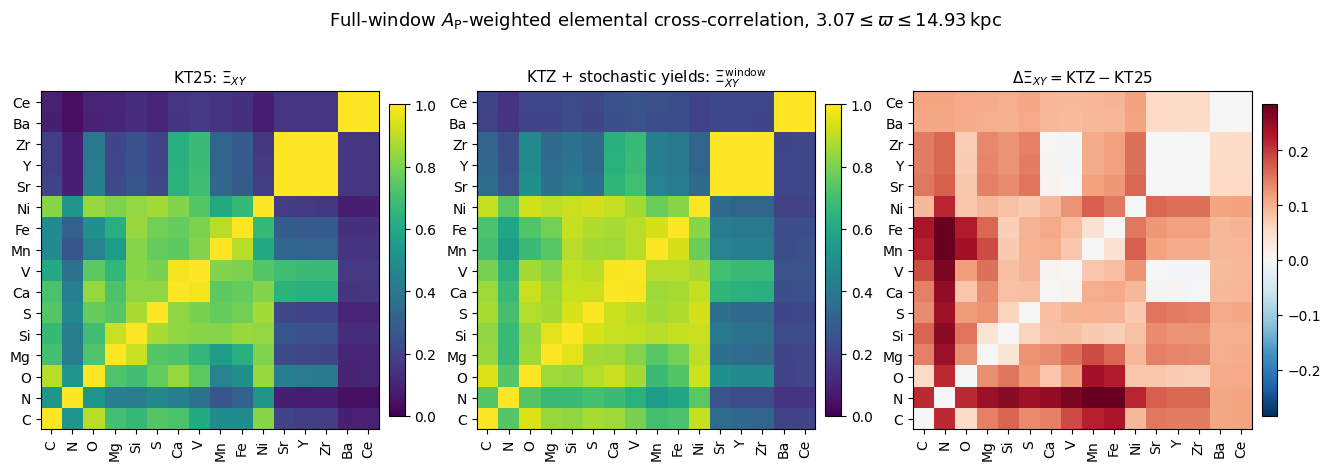

In [13]:
# %% Cross-correlation Block 4: Full-window KT25 and KTZ comparison
cross_plot_elements = [
    'C', 'N', 'O', 'Mg', 'Si', 'S', 'Ca', 'V',
    'Mn', 'Fe', 'Ni', 'Sr', 'Y', 'Zr', 'Ba', 'Ce'
]
cross_plot_index = [kt25_elements.index(e) for e in cross_plot_elements]

delta_matrix = Xi_KTZ_window - Xi_KT25
delta_limit = np.nanmax(np.abs(
    delta_matrix[np.ix_(cross_plot_index, cross_plot_index)]
))

matrix_specs = [
    (Xi_KT25, r'KT25: $\Xi_{XY}$', 'viridis', 0.0, 1.0, None),
    (
        Xi_KTZ_window,
        r'KTZ + stochastic yields: $\Xi_{XY}^{\rm window}$',
        'viridis', 0.0, 1.0, None
    ),
    (
        delta_matrix,
        r'$\Delta\Xi_{XY}={\rm KTZ}-{\rm KT25}$',
        'RdBu_r', -delta_limit, delta_limit,
        TwoSlopeNorm(vmin=-delta_limit, vcenter=0.0, vmax=delta_limit)
    ),
]

fig, axes = plt.subplots(1, 3, figsize=(13.2, 4.8), constrained_layout=True)
for ax, (matrix, title, cmap, vmin, vmax, norm) in zip(axes, matrix_specs):
    subset = matrix[np.ix_(cross_plot_index, cross_plot_index)]
    image = ax.imshow(
        subset, origin='lower', cmap=cmap,
        vmin=None if norm is not None else vmin,
        vmax=None if norm is not None else vmax,
        norm=norm
    )
    ax.set_xticks(range(len(cross_plot_elements)))
    ax.set_yticks(range(len(cross_plot_elements)))
    ax.set_xticklabels(cross_plot_elements, rotation=90)
    ax.set_yticklabels(cross_plot_elements)
    ax.set_title(title, fontsize=11)
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.03)

fig.suptitle(
    fr'Full-window $A_{{\rm P}}$-weighted elemental cross-correlation, '
    fr'${cross_analysis_R_in:.2f}\leq\varpi\leq{cross_analysis_R_out:.2f}\,$kpc',
    fontsize=13
)
plt.show()

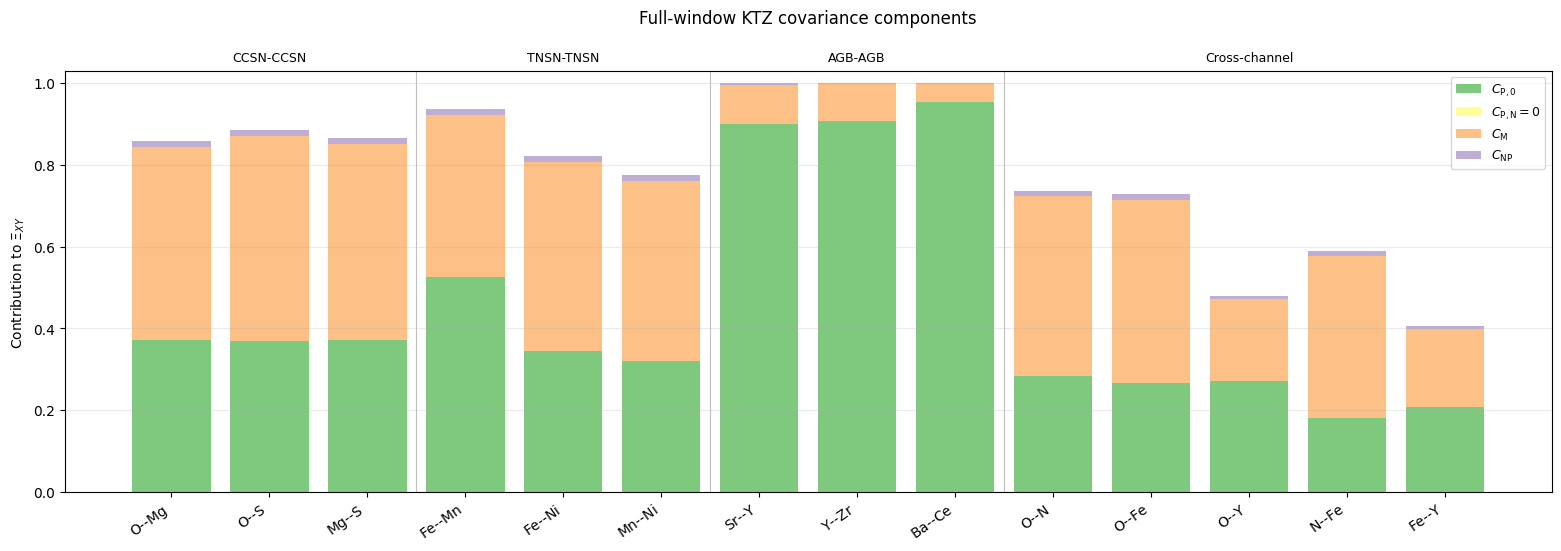

In [14]:
# %% Cross-correlation Block 5: Full-window covariance components
# The numerical validation below keeps a smaller representative subset.
cross_pair_groups = {
    'CCSN-CCSN': [('O', 'Mg')],
    'TNSN-TNSN': [('Fe', 'Ni')],
    'AGB-AGB': [('Sr', 'Y')],
    'Cross-channel': [('O', 'N'), ('O', 'Fe')],
}
cross_pairs = [
    pair
    for pairs in cross_pair_groups.values()
    for pair in pairs
]

component_pair_groups = {
    'CCSN-CCSN': [
        ('O', 'Mg'), ('O', 'S'), ('Mg', 'S')
    ],
    'TNSN-TNSN': [
        ('Fe', 'Mn'), ('Fe', 'Ni'), ('Mn', 'Ni')
    ],
    'AGB-AGB': [
        ('Sr', 'Y'), ('Y', 'Zr'), ('Ba', 'Ce')
    ],
    'Cross-channel': [
        ('O', 'N'), ('O', 'Fe'), ('O', 'Y'),
        ('N', 'Fe'), ('Fe', 'Y')
    ],
}
component_pairs = [
    pair
    for pairs in component_pair_groups.values()
    for pair in pairs
]
component_pair = {
    name: [] for name in component_order
}
plot_component_labels = component_labels.copy()
plot_component_labels['CPN'] = r'$C_{\rm P,N}=0$'

for element_a, element_b in component_pairs:
    i = kt25_elements.index(element_a)
    j = kt25_elements.index(element_b)
    denominator = np.sqrt(
        Cov_KTZ_window[i, i] * Cov_KTZ_window[j, j]
    )
    for name in component_pair:
        component_pair[name].append(
            ktz_window_components[name][i, j]
            / denominator
        )

x_pair = np.arange(len(component_pairs))
fig, ax = plt.subplots(
    figsize=(15.5, 5.4), constrained_layout=True
)
bottom = np.zeros(len(component_pairs))
for name in component_order:
    values = np.asarray(component_pair[name])
    ax.bar(
        x_pair, values, bottom=bottom,
        color=component_colors[name],
        label=plot_component_labels[name]
    )
    bottom += values

group_start = 0
for group_index, (group_name, pairs) in enumerate(
    component_pair_groups.items()
):
    group_end = group_start + len(pairs)
    group_center = 0.5 * (
        group_start + group_end - 1
    )
    ax.text(
        group_center, 1.015, group_name,
        ha='center', va='bottom', fontsize=9,
        transform=ax.get_xaxis_transform()
    )
    if group_index > 0:
        ax.axvline(
            group_start - 0.5, color='0.75', lw=0.8
        )
    group_start = group_end

ax.set_xticks(x_pair)
ax.set_xticklabels([
    fr'$\mathrm{{{a}}}$--$\mathrm{{{b}}}$'
    for a, b in component_pairs
], rotation=35, ha='right')
ax.set_ylabel(r'Contribution to $\Xi_{XY}$')
ax.set_ylim(0, 1.03)
ax.set_title(
    r'Full-window KTZ covariance components',
    pad=34
)
ax.grid(axis='y', alpha=0.25)
ax.legend(fontsize=9, loc='upper right')
plt.show()


## Numerical validation of elemental cross-correlation

The simulation samples the full KT25 parent-event rate on a $50\,\mathrm{pc}$ grid. All elements share parent positions, event masses, clustering, and stellar velocities; channel delays, injection widths, drift, diffusion, and stochastic yields determine their return fields. The theory includes the matched pixel response
$$
\sigma_{a,\mathrm{pixel}}^2
=\sigma_a^2+\frac{\Delta x_{\rm cross}^2}{12}.
$$


In [15]:
# %% Cross-correlation Block 6: Multi-element KTZ numerical realizations
from scipy.ndimage import gaussian_filter

cross_validation_elements = cross_plot_elements.copy()
cross_validation_index = np.array([
    kt25_elements.index(element)
    for element in cross_validation_elements
])
cross_saved_elements = ['O', 'N']
cross_saved_index = np.array([
    cross_validation_elements.index(element)
    for element in cross_saved_elements
])
cross_validation_n_realizations = 12
cross_age_bins = 40
# Nearest-cell deposition imposes a finite numerical response. Approximating
# the square pixel by a Gaussian with the same one-dimensional variance gives
# sigma_pix = cross_dx/sqrt(12).
cross_pixel_sigma = np.sqrt(
    kt25_sigma_inj**2 + cross_dx**2 / 12.0
)
cross_source_padding = 6.0
cross_source_R_in = max(0.30, R_in - cross_source_padding)
cross_source_R_out = R_out + cross_source_padding
cross_grid_radius = cross_source_R_out
cross_grid_x = np.arange(
    -cross_grid_radius,
    cross_grid_radius + cross_dx,
    cross_dx
)
cross_grid_y = cross_grid_x.copy()
cross_X, cross_Y = np.meshgrid(cross_grid_x, cross_grid_y)
cross_R = np.hypot(cross_X, cross_Y)
cross_disk_mask = (cross_R >= R_in) & (cross_R <= R_out)
cross_analysis_mask = (
    (cross_R >= cross_analysis_R_in)
    & (cross_R <= cross_analysis_R_out)
)

cross_radii_test = np.round(np.linspace(
    cross_analysis_R_in + 0.5,
    cross_analysis_R_out - 0.5,
    6
), 2)


def cross_endpoint_window_ok(varpi, phi, separation, psi):
    midpoint_x = varpi * np.cos(phi)
    midpoint_y = varpi * np.sin(phi)
    half_x = 0.5 * separation * np.cos(psi)
    half_y = 0.5 * separation * np.sin(psi)
    radius_minus = np.hypot(
        midpoint_x - half_x, midpoint_y - half_y
    )
    radius_plus = np.hypot(
        midpoint_x + half_x, midpoint_y + half_y
    )
    return (
        cross_analysis_R_in <= radius_minus
        and radius_minus <= cross_analysis_R_out
        and cross_analysis_R_in <= radius_plus
        and radius_plus <= cross_analysis_R_out
    )


def _radial_rate_integral(radius_min, radius_max):
    def primitive(radius):
        return -h_R * (radius + h_R) * np.exp(-radius / h_R)
    return primitive(radius_max) - primitive(radius_min)


cross_expected_parent_events = (
    2 * np.pi * kt25_Gamma * kt25_t_corr
    * _radial_rate_integral(cross_source_R_in, cross_source_R_out)
)
# Inverse CDF for the axisymmetric radial density
# p(varpi) proportional to varpi exp(-varpi/h_R).
_cross_radius_table = np.linspace(
    cross_source_R_in, cross_source_R_out, 20000
)
_cross_radius_cdf = np.array([
    _radial_rate_integral(cross_source_R_in, radius)
    for radius in _cross_radius_table
])
_cross_radius_cdf /= _cross_radius_cdf[-1]
_cross_rate_contrast_max = np.max(
    1.0 + eta * h_func(Theta_check)
)


def sample_cross_parent_positions(n_sample, rng):
    """Sample the KTZ spiral-modulated parent-event intensity."""
    if n_sample <= 0:
        return np.empty(0), np.empty(0)

    radius = np.empty(0)
    phi = np.empty(0)
    while len(radius) < n_sample:
        n_needed = n_sample - len(radius)
        n_candidate = max(2 * n_needed, 256)
        candidate_radius = np.interp(
            rng.uniform(size=n_candidate),
            _cross_radius_cdf,
            _cross_radius_table
        )
        candidate_phi = rng.uniform(
            0.0, 2 * np.pi, n_candidate
        )
        theta = spiral_phase(candidate_radius, candidate_phi)
        contrast = 1.0 + eta * h_func(theta)
        accept = (
            rng.uniform(size=n_candidate)
            < contrast / _cross_rate_contrast_max
        )
        radius = np.concatenate((radius, candidate_radius[accept]))
        phi = np.concatenate((phi, candidate_phi[accept]))

    return radius[:n_sample], phi[:n_sample]


def sample_cross_clustered_positions(n_child_target, rng):
    """Draw Thomas-process children around shared parent complexes."""
    if n_child_target <= 0:
        return np.empty(0), np.empty(0)

    child_x = np.empty(0)
    child_y = np.empty(0)
    while len(child_x) < n_child_target:
        deficit = n_child_target - len(child_x)
        n_parent = max(
            rng.poisson(deficit / mean_children_per_cluster), 1
        )
        parent_radius, parent_phi = sample_cross_parent_positions(
            n_parent, rng
        )
        parent_x = parent_radius * np.cos(parent_phi)
        parent_y = parent_radius * np.sin(parent_phi)
        child_count = rng.poisson(
            mean_children_per_cluster, n_parent
        )
        n_child = int(np.sum(child_count))
        if n_child == 0:
            continue

        x = (
            np.repeat(parent_x, child_count)
            + rng.normal(0.0, cluster_radius, n_child)
        )
        y = (
            np.repeat(parent_y, child_count)
            + rng.normal(0.0, cluster_radius, n_child)
        )
        radius = np.hypot(x, y)
        keep = (
            (radius >= cross_source_R_in)
            & (radius <= cross_source_R_out)
        )
        child_x = np.concatenate((child_x, x[keep]))
        child_y = np.concatenate((child_y, y[keep]))

    return child_x[:n_child_target], child_y[:n_child_target]


def sample_event_mass(n_event, rng):
    """Sample p(M_star) proportional to M_star^-2."""
    inverse_mass = (
        1.0 / float(slug_moments['cmf_min'])
        - rng.uniform(size=n_event)
        * (
            1.0 / float(slug_moments['cmf_min'])
            - 1.0 / float(slug_moments['cmf_max'])
        )
    )
    return 1.0 / inverse_mass


cross_mean_yield = kt25_mean_yield[cross_validation_index]
cross_delay = kt25_delay[cross_validation_index]
cross_flat_index = np.array([
    element_index * len(kt25_channels) + channel_index
    for element_index in cross_validation_index
    for channel_index in range(len(kt25_channels))
])
cross_K = kt25_imf_cov_per_mass.reshape(
    len(kt25_elements) * len(kt25_channels),
    len(kt25_elements) * len(kt25_channels)
)[np.ix_(cross_flat_index, cross_flat_index)]
cross_K = 0.5 * (cross_K + cross_K.T)
cross_K_eigenvalue, cross_K_eigenvector = np.linalg.eigh(cross_K)
cross_K_factor = (
    cross_K_eigenvector
    * np.sqrt(np.clip(cross_K_eigenvalue, 0.0, None))
)


def sample_cross_event_yields(event_mass, rng):
    """Sample joint channel yields with the SLUG same-event second moment."""
    n_event = len(event_mass)
    mean_flat = cross_mean_yield.reshape(-1)
    stochastic_residual = (
        rng.normal(size=(n_event, len(mean_flat)))
        @ cross_K_factor.T
    )
    event_yield = (
        event_mass[:, None] * mean_flat[None, :]
        + np.sqrt(event_mass)[:, None] * stochastic_residual
    )
    return event_yield.reshape(
        n_event,
        len(cross_validation_elements),
        len(kt25_channels)
    )


def _deposit_gaussian(return_x, return_y, weight, sigma):
    """Deposit weighted events and convolve with a normalized Gaussian."""
    nx = len(cross_grid_x)
    ny = len(cross_grid_y)
    ix = np.floor(
        (return_x - cross_grid_x[0]) / cross_dx + 0.5
    ).astype(int)
    iy = np.floor(
        (return_y - cross_grid_y[0]) / cross_dx + 0.5
    ).astype(int)
    inside = (
        (ix >= 0) & (ix < nx)
        & (iy >= 0) & (iy < ny)
        & np.isfinite(weight)
    )
    source = np.bincount(
        iy[inside] * nx + ix[inside],
        weights=weight[inside],
        minlength=nx * ny
    ).reshape(ny, nx)
    return gaussian_filter(
        source,
        sigma=max(sigma / cross_dx, 1.0e-3),
        mode='constant',
        cval=0.0,
        truncate=5.0
    ) / cross_dx**2


def cross_axisymmetric_mean_fields():
    """Return the axisymmetric ensemble means on the cross grid."""
    safe_radius = np.maximum(cross_R, cross_source_R_in)
    local_rate = kt25_Gamma * np.exp(-safe_radius / h_R)
    axisymmetric = np.zeros(
        (len(cross_validation_elements), *cross_R.shape)
    )
    for element_index in range(len(cross_validation_elements)):
        response = 0.0
        for channel_index in range(len(kt25_channels)):
            delay = cross_delay[element_index, channel_index]
            if delay < kt25_t_corr:
                response += (
                    cross_mean_yield[element_index, channel_index]
                    * (kt25_t_corr - delay)
                )
        axisymmetric[element_index] = (
            local_rate * kt25_event_mass_mean * response
        )
    return axisymmetric


cross_axisymmetric_mean = cross_axisymmetric_mean_fields()


def generate_cross_ktz_realization(rng):
    """Generate one multi-element KTZ realization and its residual fields."""
    n_event = rng.poisson(cross_expected_parent_events)
    if enable_source_clustering and cluster_fraction > 0:
        n_clustered = rng.binomial(n_event, cluster_fraction)
    else:
        n_clustered = 0
    n_poisson = n_event - n_clustered

    poisson_radius, poisson_phi = sample_cross_parent_positions(
        n_poisson, rng
    )
    poisson_x = poisson_radius * np.cos(poisson_phi)
    poisson_y = poisson_radius * np.sin(poisson_phi)
    clustered_x, clustered_y = sample_cross_clustered_positions(
        n_clustered, rng
    )
    event_x = np.concatenate((poisson_x, clustered_x))
    event_y = np.concatenate((poisson_y, clustered_y))
    permutation = rng.permutation(n_event)
    event_x = event_x[permutation]
    event_y = event_y[permutation]

    event_age = rng.uniform(0.0, kt25_t_corr, n_event)
    velocity_x = rng.normal(0.0, kt25_sigma_v, n_event)
    velocity_y = rng.normal(0.0, kt25_sigma_v, n_event)
    event_mass = sample_event_mass(n_event, rng)
    event_yield = sample_cross_event_yields(event_mass, rng)

    fields = np.zeros(
        (len(cross_validation_elements), *cross_R.shape)
    )
    for element_index in range(len(cross_validation_elements)):
        for channel_index in range(len(kt25_channels)):
            delay = cross_delay[element_index, channel_index]
            duration = kt25_t_corr - delay
            if (
                duration <= 0
                or not np.any(
                    event_yield[:, element_index, channel_index] != 0
                )
            ):
                continue

            return_x = event_x + velocity_x * delay
            return_y = event_y + velocity_y * delay
            time_since_return = event_age - delay
            # The covariance integral is logarithmically sensitive to
            # newly returned material, especially for the 1 pc AGB kernel.
            # Uniform age bins would erase this contribution. Use bins that
            # are uniform in log(sigma_diffusion^2) instead.
            sigma_injection2 = kt25_sigma_inj[channel_index]**2
            width2_edges = np.geomspace(
                sigma_injection2,
                sigma_injection2 + 2 * kt25_kappa * duration,
                cross_age_bins + 1
            )
            age_edges = (
                width2_edges - sigma_injection2
            ) / (2 * kt25_kappa)
            for bin_index, (lower, upper) in enumerate(zip(
                age_edges[:-1], age_edges[1:]
            )):
                selected = (
                    (time_since_return >= lower)
                    & (time_since_return < upper)
                )
                if not np.any(selected):
                    continue
                width2_midpoint = np.sqrt(
                    width2_edges[bin_index]
                    * width2_edges[bin_index + 1]
                )
                sigma = np.sqrt(width2_midpoint)
                fields[element_index] += _deposit_gaussian(
                    return_x[selected],
                    return_y[selected],
                    event_yield[
                        selected, element_index, channel_index
                    ],
                    sigma
                )

    residual = fields - cross_axisymmetric_mean
    residual[:, ~cross_disk_mask] = np.nan
    values = residual[:, cross_analysis_mask]
    covariance = values @ values.T / values.shape[1]
    # Retain only O and N maps between realizations. The full element set has
    # already contributed to the covariance matrices above.
    return {
        'fields': fields[cross_saved_index].astype(np.float32),
        'residual': residual[cross_saved_index].astype(np.float32),
        'covariance': covariance,
        'n_event': n_event,
    }


cross_validation_rng = default_rng(20260625)
cross_validation_realizations = []
for realization_index in range(cross_validation_n_realizations):
    realization = generate_cross_ktz_realization(
        cross_validation_rng
    )
    cross_validation_realizations.append(realization)
    print(
        f'KTZ cross realization {realization_index + 1}/'
        f'{cross_validation_n_realizations}: '
        f'{realization["n_event"]:,} sampled parent events'
    )

cross_covariance_stack = np.stack([
    realization['covariance']
    for realization in cross_validation_realizations
])
cross_simulation_covariance = np.mean(
    cross_covariance_stack, axis=0
)
# KTZ predicts a Pearson coefficient constructed from ensemble covariance:
# E[C_XY] / sqrt(E[C_XX] E[C_YY]), not the mean of separately normalized
# single-realization Pearson coefficients.
cross_simulation_mean = normalize_cross_covariance(
    cross_simulation_covariance
)

cross_bootstrap_count = 1000
cross_bootstrap_rng = default_rng(20260626)
cross_bootstrap_correlation = np.empty(
    (
        cross_bootstrap_count,
        len(cross_validation_elements),
        len(cross_validation_elements)
    )
)
for bootstrap_index in range(cross_bootstrap_count):
    selection = cross_bootstrap_rng.integers(
        0, cross_validation_n_realizations,
        cross_validation_n_realizations
    )
    covariance = np.mean(
        cross_covariance_stack[selection], axis=0
    )
    cross_bootstrap_correlation[bootstrap_index] = (
        normalize_cross_covariance(covariance)
    )
cross_simulation_std = np.std(
    cross_bootstrap_correlation, axis=0, ddof=1
)
cross_pixel_components = compute_ktz_window_components(
    cross_pixel_sigma
)
cross_pixel_covariance = sum(cross_pixel_components.values())
Xi_KTZ_pixel = normalize_cross_covariance(
    cross_pixel_covariance
)
cross_theory_subset = Xi_KTZ_pixel[
    np.ix_(cross_validation_index, cross_validation_index)
]
print(
    f'Cross simulation: {cross_expected_parent_events:,.0f} '
    f'events per realization, '
    f'{1000 * cross_dx:.0f} pc pixels'
)


KTZ cross realization 1/12: 1,128,529 sampled parent events


KTZ cross realization 2/12: 1,127,662 sampled parent events


KTZ cross realization 3/12: 1,129,347 sampled parent events


KTZ cross realization 4/12: 1,129,117 sampled parent events


KTZ cross realization 5/12: 1,128,836 sampled parent events


...

KTZ cross realization 8/12: 1,130,053 sampled parent events


KTZ cross realization 9/12: 1,129,736 sampled parent events


KTZ cross realization 10/12: 1,128,056 sampled parent events


KTZ cross realization 11/12: 1,128,060 sampled parent events


KTZ cross realization 12/12: 1,129,595 sampled parent events
Cross simulation: 1,128,918 events per realization, 50 pc pixels


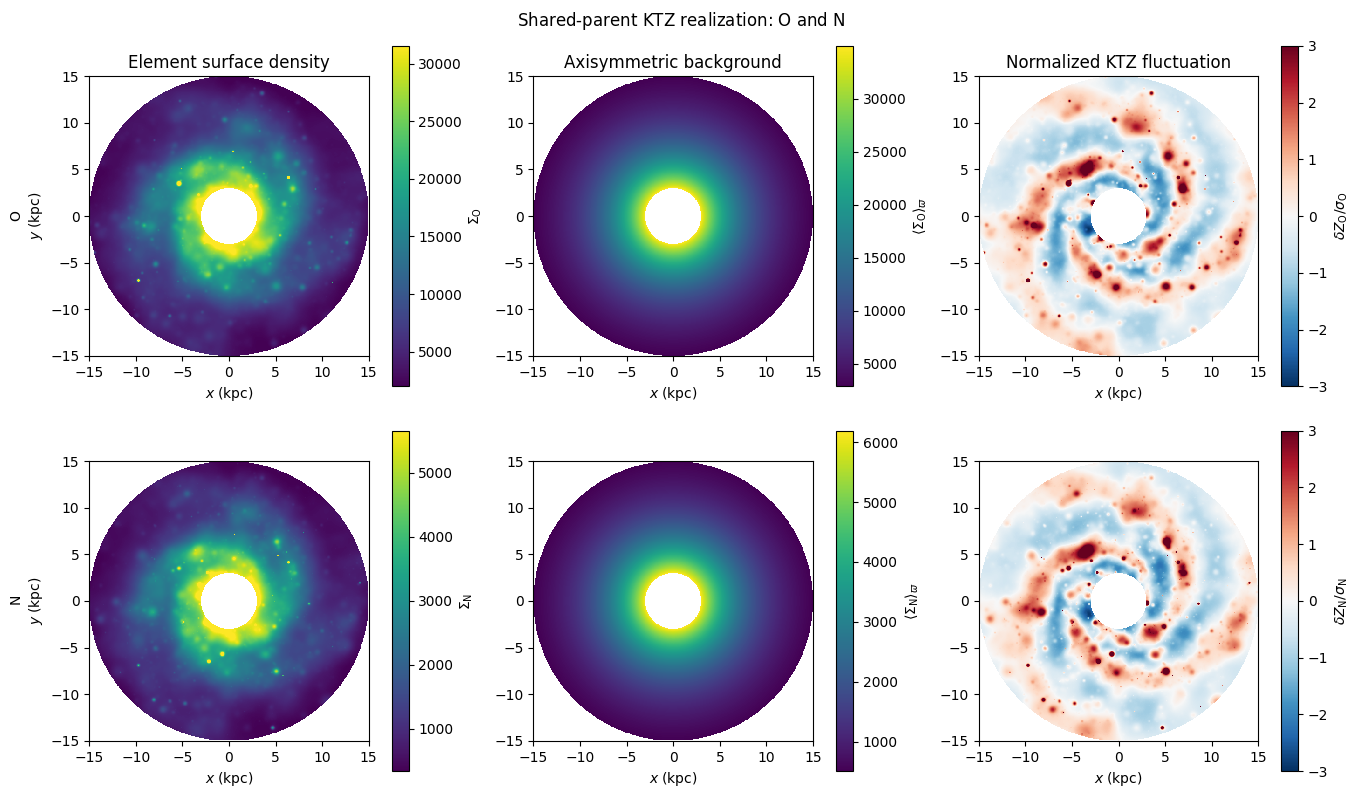

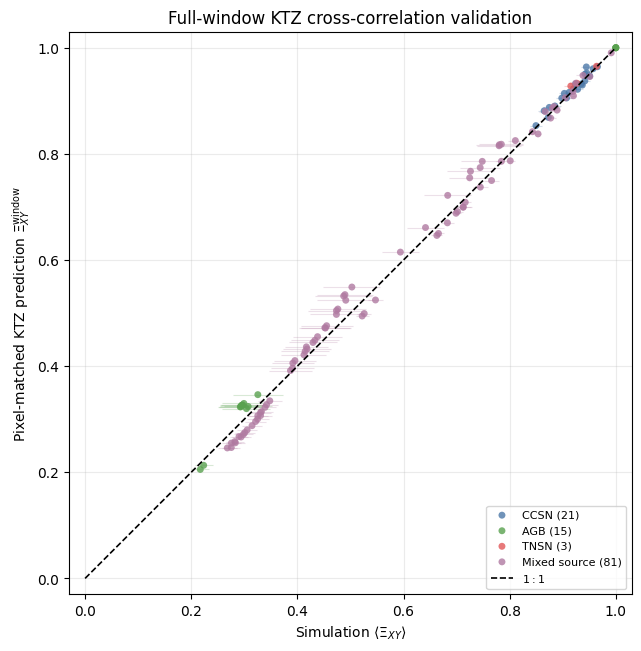

All-pair validation: RMSE=0.020, mean(simulation - KTZ)=-0.004, Pearson r=0.997


In [953]:
# %% Cross-correlation Block 7: O/N fluctuations and KTZ validation
display_realization = cross_validation_realizations[0]
display_elements = cross_saved_elements

fig, axes = plt.subplots(
    len(display_elements), 3,
    figsize=(13.5, 8.0),
    constrained_layout=True
)
for row, element in enumerate(display_elements):
    saved_index = cross_saved_elements.index(element)
    element_index = cross_validation_elements.index(element)
    field = display_realization['fields'][saved_index]
    residual = display_realization['residual'][saved_index]
    background = cross_axisymmetric_mean[element_index]
    variance = np.nanmean(
        residual[cross_analysis_mask]**2
    )
    standardized = residual / np.sqrt(variance)

    field_plot = np.where(cross_disk_mask, field, np.nan)
    background_plot = np.where(
        cross_disk_mask, background, np.nan
    )
    residual_plot = np.where(cross_disk_mask, standardized, np.nan)

    field_vmin, field_vmax = np.nanpercentile(
        field_plot, [1, 99]
    )
    image = axes[row, 0].pcolormesh(
        cross_X, cross_Y, field_plot,
        shading='auto', cmap='viridis',
        vmin=field_vmin, vmax=field_vmax
    )
    fig.colorbar(
        image, ax=axes[row, 0],
        label=fr'$\Sigma_{{\mathrm{{{element}}}}}$'
    )

    image = axes[row, 1].pcolormesh(
        cross_X, cross_Y, background_plot,
        shading='auto', cmap='viridis'
    )
    fig.colorbar(
        image, ax=axes[row, 1],
        label=fr'$\langle\Sigma_{{\mathrm{{{element}}}}}\rangle_\varpi$'
    )

    image = axes[row, 2].pcolormesh(
        cross_X, cross_Y, residual_plot,
        shading='auto', cmap='RdBu_r',
        vmin=-3.0, vmax=3.0
    )
    fig.colorbar(
        image, ax=axes[row, 2],
        label=(
            r'$\delta Z_{\mathrm{' + element
            + r'}}/\sigma_{\mathrm{' + element + r'}}$'
        )
    )

    axes[row, 0].set_ylabel(
        fr'$\mathrm{{{element}}}$' + '\n' + r'$y\;(\mathrm{kpc})$'
    )

for column, title in enumerate([
    r'Element surface density',
    r'Axisymmetric background',
    r'Normalized KTZ fluctuation'
]):
    axes[0, column].set_title(title)

for ax in axes.flat:
    ax.set_xlim(-R_out, R_out)
    ax.set_ylim(-R_out, R_out)
    ax.set_aspect('equal')
    ax.set_xlabel(r'$x\;(\mathrm{kpc})$')

fig.suptitle(
    r'Shared-parent KTZ realization: $\mathrm{O}$ and $\mathrm{N}$'
)
plt.show()


validation_indices = np.triu_indices(

    len(cross_validation_elements), k=1

)

all_simulation = cross_simulation_mean[

    validation_indices

]

all_simulation_error = cross_simulation_std[

    validation_indices

]

all_theory = cross_theory_subset[

    validation_indices

]

assert len(all_simulation) == 120



channel_display = {

    'snii': 'CCSN',

    'agb': 'AGB',

    'snia': 'TNSN',

}

channel_colors = {

    'CCSN': '#4c78a8',

    'AGB': '#59a14f',

    'TNSN': '#e15759',

    'Mixed source': '#b07aa1',

}

element_main_source = np.array([

    channel_display[kt25_channels[index]]

    for index in np.argmax(

        np.abs(kt25_mean_yield[cross_validation_index]), axis=1

    )

])

pair_source_a = element_main_source[validation_indices[0]]

pair_source_b = element_main_source[validation_indices[1]]

dominant_channel = np.where(

    pair_source_a == pair_source_b,

    pair_source_a,

    'Mixed source'

)



fig, ax = plt.subplots(

    figsize=(7.2, 6.4), constrained_layout=True

)

for label in ['CCSN', 'AGB', 'TNSN', 'Mixed source']:

    selected = dominant_channel == label

    if not np.any(selected):

        continue

    ax.errorbar(

        all_simulation[selected], all_theory[selected],

        xerr=all_simulation_error[selected],

        fmt='none', ecolor=channel_colors[label],

        elinewidth=0.8, alpha=0.23,

        capsize=0, zorder=1

    )

    ax.scatter(

        all_simulation[selected], all_theory[selected],

        s=25, color=channel_colors[label],

        alpha=0.80, edgecolors='none',

        label=f'{label} ({np.sum(selected)})', zorder=2

    )



plot_min = min(
    0.0, np.min(all_simulation), np.min(all_theory)
)
plot_max = max(
    1.0, np.max(all_simulation), np.max(all_theory)
)
ax.plot(
    [plot_min, plot_max],
    [plot_min, plot_max],
    'k--', lw=1.2, label=r'$1{:}1$'
)
ax.set_xlim(plot_min - 0.03, plot_max + 0.03)
ax.set_ylim(plot_min - 0.03, plot_max + 0.03)
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel(r'Simulation $\langle\Xi_{XY}\rangle$')
ax.set_ylabel(
    r'Pixel-matched KTZ prediction '
    r'$\Xi_{XY}^{\rm window}$'
)
ax.set_title(
    r'Full-window KTZ cross-correlation validation'
)
ax.grid(alpha=0.25)
ax.legend(fontsize=8, loc='lower right')
plt.show()

validation_rmse = np.sqrt(np.mean(
    (all_simulation - all_theory)**2
))
validation_bias = np.mean(
    all_simulation - all_theory
)
validation_pearson = np.corrcoef(
    all_simulation, all_theory
)[0, 1]
print(
    f'All-pair validation: RMSE={validation_rmse:.3f}, '
    f'mean(simulation - KTZ)={validation_bias:+.3f}, '
    f'Pearson r={validation_pearson:.3f}'
)


## O and N auto-correlation from the shared ensemble
### This part may not be as important as previous two, I won't include it into the paper 
The following $\mathrm{O}$--$\mathrm{O}$ and $\mathrm{N}$--$\mathrm{N}$ measurements use the same multi-element realizations as the cross-correlation test. Their KTZ curves include stochastic yields, channel delays, stellar drift, source clustering, the spiral mean field, and the $50\,\mathrm{pc}$ pixel response.


In [948]:
# %% Cross-correlation Block 8: Shared O-O and N-N xi2/xi3
cross_auto_elements = cross_saved_elements
cross_auto_index = np.arange(len(cross_auto_elements))
cross_auto_colors = {
    'O': '#1b9e77',
    'N': '#d95f02',
}


def _measure_shared_auto(
    residual_cube, rng, midpoint_radius=None
):
    num_sample = (
        num_pairs if midpoint_radius is not None
        else num_pairs_xi3
    )
    if midpoint_radius is None:
        midpoint_radius = np.sqrt(rng.uniform(
            cross_analysis_R_in**2,
            cross_analysis_R_out**2,
            num_sample
        ))
    else:
        midpoint_radius = np.full(
            num_sample, midpoint_radius
        )

    midpoint_phi = rng.uniform(
        0.0, 2 * np.pi, num_sample
    )
    separation_phi = rng.uniform(
        0.0, 2 * np.pi, num_sample
    )
    separation = rng.uniform(
        r_bins[0], r_bins[-1], num_sample
    )
    midpoint_x = midpoint_radius * np.cos(midpoint_phi)
    midpoint_y = midpoint_radius * np.sin(midpoint_phi)
    half_x = 0.5 * separation * np.cos(separation_phi)
    half_y = 0.5 * separation * np.sin(separation_phi)
    minus_x, minus_y = midpoint_x - half_x, midpoint_y - half_y
    plus_x, plus_y = midpoint_x + half_x, midpoint_y + half_y
    valid = (
        (np.hypot(minus_x, minus_y) >= cross_analysis_R_in)
        & (np.hypot(minus_x, minus_y) <= cross_analysis_R_out)
        & (np.hypot(plus_x, plus_y) >= cross_analysis_R_in)
        & (np.hypot(plus_x, plus_y) <= cross_analysis_R_out)
    )
    minus_points = np.column_stack((
        minus_x[valid], minus_y[valid]
    ))
    plus_points = np.column_stack((
        plus_x[valid], plus_y[valid]
    ))
    valid_separation = separation[valid]

    result = {}
    for element, index in zip(
        cross_auto_elements, cross_auto_index
    ):
        interpolator = RegularGridInterpolator(
            (cross_grid_x, cross_grid_y),
            residual_cube[index].T,
            bounds_error=False,
            fill_value=np.nan
        )
        minus_value = interpolator(minus_points)
        plus_value = interpolator(plus_points)
        correlation = np.full(len(r_centers), np.nan)
        for bin_index, (lower, upper) in enumerate(
            zip(r_bins[:-1], r_bins[1:])
        ):
            selected = (
                (valid_separation >= lower)
                & (valid_separation < upper)
                & np.isfinite(minus_value)
                & np.isfinite(plus_value)
            )
            if np.sum(selected) <= 10:
                continue
            z_minus = minus_value[selected]
            z_plus = plus_value[selected]
            denominator = np.sqrt(
                np.mean(z_minus**2)
                * np.mean(z_plus**2)
            )
            if denominator > 0:
                correlation[bin_index] = np.mean(
                    z_minus * z_plus
                ) / denominator
        result[element] = correlation
    return result


cross_auto_rng = default_rng(20260627)
cross_auto_xi2_realizations = []
cross_auto_xi3_realizations = []
for realization_index, realization in enumerate(
    cross_validation_realizations
):
    cross_auto_xi2_realizations.append({
        radius: _measure_shared_auto(
            realization['residual'],
            cross_auto_rng,
            midpoint_radius=radius
        )
        for radius in cross_radii_test
    })
    cross_auto_xi3_realizations.append(
        _measure_shared_auto(
            realization['residual'], cross_auto_rng
        )
    )
    print(
        f'Shared O/N auto-correlation '
        f'{realization_index + 1}/'
        f'{cross_validation_n_realizations}'
    )

cross_auto_xi2_mean = {
    element: {
        radius: np.nanmean(np.vstack([
            realization[radius][element]
            for realization in cross_auto_xi2_realizations
        ]), axis=0)
        for radius in cross_radii_test
    }
    for element in cross_auto_elements
}
cross_auto_xi2_std = {
    element: {
        radius: np.nanstd(np.vstack([
            realization[radius][element]
            for realization in cross_auto_xi2_realizations
        ]), axis=0, ddof=1)
        for radius in cross_radii_test
    }
    for element in cross_auto_elements
}
cross_auto_xi3_mean = {
    element: np.nanmean(np.vstack([
        realization[element]
        for realization in cross_auto_xi3_realizations
    ]), axis=0)
    for element in cross_auto_elements
}
cross_auto_xi3_std = {
    element: np.nanstd(np.vstack([
        realization[element]
        for realization in cross_auto_xi3_realizations
    ]), axis=0, ddof=1)
    for element in cross_auto_elements
}


# Multi-channel KTZ auto-correlation theory for the same 50 pc response.
from scipy.special import j0, dawsn

cross_auto_theory_mask = r_centers <= correlation_plot_rmax
cross_auto_theory_r = r_centers[cross_auto_theory_mask]
cross_auto_kmax = max(
    120.0, 10.0 / np.min(cross_pixel_sigma)
)
cross_auto_k = np.linspace(
    1.0e-5, cross_auto_kmax, 24000
)


def ktz_element_cp0_spectrum(element):
    """Same-parent multi-channel KTZ spectrum before the Hankel transform."""
    element_index = kt25_elements.index(element)
    spectrum = np.zeros_like(cross_auto_k)
    for channel_a in range(len(kt25_channels)):
        delay_a = kt25_delay[element_index, channel_a]
        ell_a2 = kt25_kappa * delay_a
        for channel_b in range(len(kt25_channels)):
            second_moment = kt25_second_yield_normalized[
                element_index, channel_a,
                element_index, channel_b
            ]
            if second_moment == 0:
                continue
            delay_b = kt25_delay[element_index, channel_b]
            ell_b2 = kt25_kappa * delay_b
            injection = np.exp(
                -0.5 * (
                    cross_pixel_sigma[channel_a]**2
                    + cross_pixel_sigma[channel_b]**2
                ) * cross_auto_k**2
            )
            age_window = (
                np.exp(
                    -abs(ell_a2 - ell_b2)
                    * cross_auto_k**2
                )
                - np.exp(
                    (
                        ell_a2 + ell_b2
                        - 2 * kt25_lcorr**2
                    ) * cross_auto_k**2
                )
            )
            drift_length = (
                kt25_sigma_v * abs(delay_a - delay_b)
                / np.sqrt(2.0)
            )
            drift = (
                1.0
                - 2.0 * cross_auto_k * drift_length
                * dawsn(cross_auto_k * drift_length)
            )
            spectrum += (
                second_moment * injection
                * age_window * drift / cross_auto_k
            )
    return spectrum


def ktz_element_cp0_curve(element, radius):
    spectrum = ktz_element_cp0_spectrum(element)
    radius = np.asarray(radius)
    return np.array([
        2.0 * simpson(
            j0(cross_auto_k * separation) * spectrum,
            x=cross_auto_k
        )
        for separation in radius
    ])


def ktz_element_cnp_curve(element, radius):
    """Different-parent Thomas-process covariance at non-zero lag."""
    element_index = kt25_elements.index(element)
    transfer = np.zeros_like(k_cross)
    for channel_index in range(len(kt25_channels)):
        yield_value = kt25_mean_yield[
            element_index, channel_index
        ]
        delay = kt25_delay[element_index, channel_index]
        if yield_value == 0 or delay >= kt25_t_corr:
            continue
        duration = kt25_t_corr - delay
        diffusion = -np.expm1(
            -kt25_kappa * duration * k_cross**2
        ) / (kt25_kappa * k_cross**2)
        injection = np.exp(
            -0.5 * (
                cross_pixel_sigma[channel_index] * k_cross
            )**2
        )
        drift = np.exp(
            -0.5 * (
                kt25_sigma_v * delay * k_cross
            )**2
        )
        transfer += (
            yield_value * injection * drift * diffusion
        )

    spectral_weight = (
        cross_prefactor_0 * k_cross * P_source
        * transfer**2 / (2 * np.pi)
    )
    return np.array([
        simpson(
            j0(k_cross * separation) * spectral_weight,
            x=k_cross
        )
        for separation in np.asarray(radius)
    ])


cross_auto_cp0_theory = {}
cross_auto_cnp_theory = {}
for element in cross_auto_elements:
    radius_with_zero = np.concatenate((
        [0.0], cross_auto_theory_r
    ))
    cp0_curve = ktz_element_cp0_curve(
        element, radius_with_zero
    )
    cnp_curve = ktz_element_cnp_curve(
        element, radius_with_zero
    )
    # Use the exact analytic zero-lag matrices already validated against KT25.
    element_index = kt25_elements.index(element)
    cp0_curve[0] = cross_pixel_components['CP0'][
        element_index, element_index
    ]
    cnp_curve[0] = cross_pixel_components['CNP'][
        element_index, element_index
    ]
    cross_auto_cp0_theory[element] = cp0_curve
    cross_auto_cnp_theory[element] = cnp_curve


def cross_auto_scaled_mean(
    element, varpi, theta_value
):
    """Dimensionless spiral mean response used in C_M."""
    element_index = kt25_elements.index(element)
    q_base = k_perp(varpi)
    response_total = 0.0
    for n, g_n, alpha_n in zip(
        harmonic_n, harmonic_g, harmonic_alpha
    ):
        q_n = n * q_base
        response = 0.0
        for channel_index in range(len(kt25_channels)):
            yield_value = kt25_mean_yield[
                element_index, channel_index
            ]
            delay = kt25_delay[
                element_index, channel_index
            ]
            if yield_value == 0 or delay >= kt25_t_corr:
                continue
            duration = kt25_t_corr - delay
            diffusion = -np.expm1(
                -kt25_kappa * duration * q_n**2
            ) / (kt25_kappa * q_n**2)
            injection = np.exp(
                -0.5 * (
                    cross_pixel_sigma[channel_index] * q_n
                )**2
            )
            drift = np.exp(
                -0.5 * (
                    kt25_sigma_v * delay * q_n
                )**2
            )
            response += (
                yield_value * injection * drift * diffusion
            )
        response_total += (
            eta * g_n * _cross_harmonic_damping(q_n)
            * response * np.cos(n * theta_value + alpha_n)
        )
    return response_total


def cross_auto_theory_from_samples(
    element, separation, varpi_values,
    n_phi=24, n_psi=24
):
    """Pair-product KTZ prediction for xi2 or xi3 geometry."""
    curve_index = np.argmin(np.abs(
        np.concatenate(([0.0], cross_auto_theory_r))
        - separation
    ))
    cp0 = cross_auto_cp0_theory[element][curve_index]
    cnp = cross_auto_cnp_theory[element][curve_index]
    cp0_zero = cross_auto_cp0_theory[element][0]
    cnp_zero = cross_auto_cnp_theory[element][0]

    numerator = []
    variance_minus = []
    variance_plus = []
    weights = []
    phi_values = np.linspace(
        0.0, 2 * np.pi, n_phi, endpoint=False
    )
    psi_values = np.linspace(
        0.0, 2 * np.pi, n_psi, endpoint=False
    )

    for varpi in np.atleast_1d(varpi_values):
        rate_relative = np.exp(-varpi / h_R)
        local_prefactor = (
            cross_prefactor_0 * rate_relative
        )
        for phi_value in phi_values:
            theta_midpoint = spiral_phase(varpi, phi_value)
            d_phi = (
                m_arms / np.tan(pitch_rad) / varpi
            )
            gradient = np.array([
                d_phi * np.cos(phi_value)
                + m_arms / varpi * np.sin(phi_value),
                d_phi * np.sin(phi_value)
                - m_arms / varpi * np.cos(phi_value),
            ])
            for psi_value in psi_values:
                if not cross_endpoint_window_ok(
                    varpi, phi_value, separation, psi_value
                ):
                    continue
                separation_vector = separation * np.array([
                    np.cos(psi_value), np.sin(psi_value)
                ])
                phase_offset = 0.5 * np.dot(
                    gradient, separation_vector
                )
                theta_minus = theta_midpoint - phase_offset
                theta_plus = theta_midpoint + phase_offset
                mean_minus = cross_auto_scaled_mean(
                    element, varpi, theta_minus
                )
                mean_plus = cross_auto_scaled_mean(
                    element, varpi, theta_plus
                )

                numerator.append(
                    cp0 + cnp
                    + local_prefactor * mean_minus * mean_plus
                )
                variance_minus.append(
                    cp0_zero + cnp_zero
                    + local_prefactor * mean_minus**2
                )
                variance_plus.append(
                    cp0_zero + cnp_zero
                    + local_prefactor * mean_plus**2
                )
                weights.append(rate_relative)

    weights = np.asarray(weights)
    numerator = np.asarray(numerator)
    variance_minus = np.asarray(variance_minus)
    variance_plus = np.asarray(variance_plus)
    denominator = np.sqrt(
        np.average(variance_minus, weights=weights)
        * np.average(variance_plus, weights=weights)
    )
    return (
        np.average(numerator, weights=weights) / denominator
        if denominator > 0 else np.nan
    )


cross_auto_xi2_theory = {
    element: {
        varpi: np.array([
            cross_auto_theory_from_samples(
                element, separation, [varpi],
                n_phi=32, n_psi=32
            )
            for separation in cross_auto_theory_r
        ])
        for varpi in cross_radii_test
    }
    for element in cross_auto_elements
}

cross_auto_rho2_edges = np.linspace(
    analysis_R_in**2, analysis_R_out**2, 25
)
cross_auto_varpi_nodes = np.sqrt(
    0.5 * (
        cross_auto_rho2_edges[:-1]
        + cross_auto_rho2_edges[1:]
    )
)
cross_auto_xi3_theory = {
    element: np.array([
        cross_auto_theory_from_samples(
            element, separation,
            cross_auto_varpi_nodes,
            n_phi=16, n_psi=16
        )
        for separation in cross_auto_theory_r
    ])
    for element in cross_auto_elements
}


Shared O/N auto-correlation 1/12
Shared O/N auto-correlation 2/12
Shared O/N auto-correlation 3/12
Shared O/N auto-correlation 4/12
Shared O/N auto-correlation 5/12
Shared O/N auto-correlation 6/12
Shared O/N auto-correlation 7/12
Shared O/N auto-correlation 8/12
Shared O/N auto-correlation 9/12
Shared O/N auto-correlation 10/12
Shared O/N auto-correlation 11/12
Shared O/N auto-correlation 12/12


Shared O/N auto-correlation 3/12


Shared O/N auto-correlation 4/12
Shared O/N auto-correlation 5/12


Shared O/N auto-correlation 6/12
Shared O/N auto-correlation 7/12


Shared O/N auto-correlation 8/12
Shared O/N auto-correlation 9/12


Shared O/N auto-correlation 10/12
Shared O/N auto-correlation 11/12


Shared O/N auto-correlation 12/12


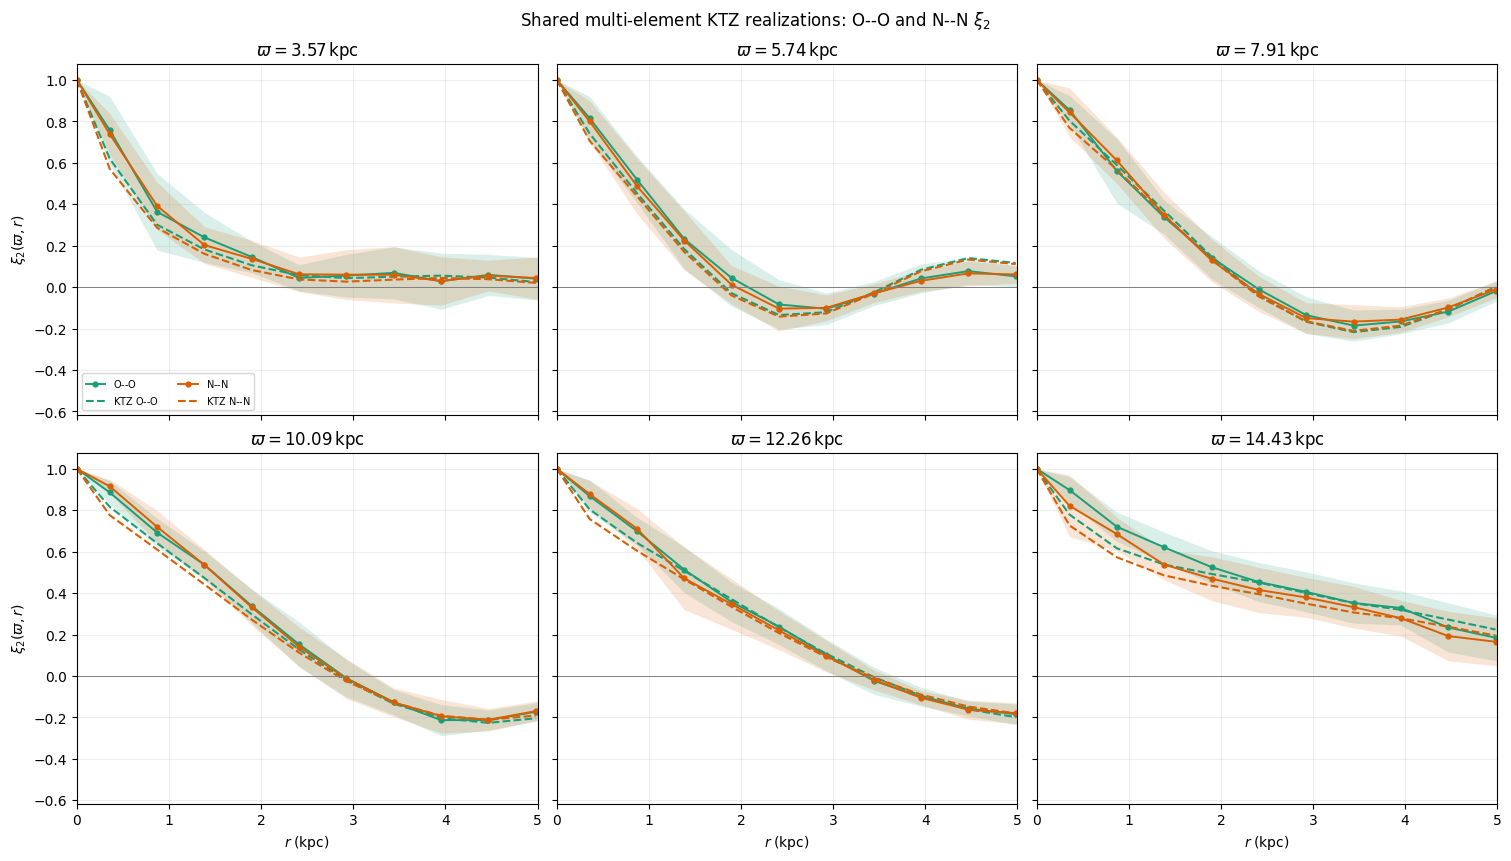

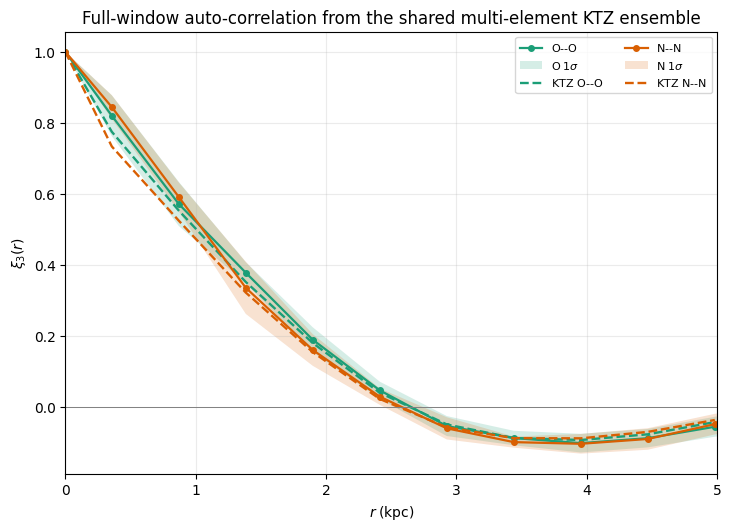

\mathrm{O}--\mathrm{O}: interpolated \xi_3=0.5 scale = 1.061 kpc
\mathrm{N}--\mathrm{N}: interpolated \xi_3=0.5 scale = 1.054 kpc


In [949]:
# %% Cross-correlation Block 9: Shared O-O and N-N xi2/xi3 plots
fig, axes = plt.subplots(
    2, 3, figsize=(15, 8.5),
    sharex=True, sharey=True,
    constrained_layout=True
)
for ax, varpi_m in zip(axes.flat, cross_radii_test):
    r_plot = np.concatenate(([0.0], r_centers))
    for element in cross_auto_elements:
        mean = np.concatenate((
            [1.0], cross_auto_xi2_mean[element][varpi_m]
        ))
        scatter = np.concatenate((
            [0.0], cross_auto_xi2_std[element][varpi_m]
        ))
        color = cross_auto_colors[element]
        ax.plot(
            r_plot, mean, 'o-',
            ms=3.5, lw=1.4, color=color,
            label=fr'$\mathrm{{{element}}}$--$\mathrm{{{element}}}$'
        )
        ax.fill_between(
            r_plot, mean - scatter, mean + scatter,
            color=color, alpha=0.16, linewidth=0
        )
        theory = np.concatenate((
            [1.0],
            cross_auto_xi2_theory[element][varpi_m]
        ))
        theory_radius = np.concatenate((
            [0.0], cross_auto_theory_r
        ))
        ax.plot(
            theory_radius, theory, '--',
            lw=1.5, color=color,
            label=fr'KTZ $\mathrm{{{element}}}$--$\mathrm{{{element}}}$'
        )
    ax.axhline(0.0, color='0.5', lw=0.7)
    ax.set_xlim(0.0, correlation_plot_rmax)
    ax.set_title(fr'$\varpi={varpi_m}\,\mathrm{{kpc}}$')
    ax.grid(alpha=0.22)

for ax in axes[-1]:
    ax.set_xlabel(r'$r\;(\mathrm{kpc})$')
for ax in axes[:, 0]:
    ax.set_ylabel(r'$\xi_2(\varpi,r)$')
axes[0, 0].legend(fontsize=7, loc='lower left', ncol=2)
fig.suptitle(
    r'Shared multi-element KTZ realizations: '
    r'$\mathrm{O}$--$\mathrm{O}$ and '
    r'$\mathrm{N}$--$\mathrm{N}$ $\xi_2$'
)
plt.show()


fig, ax = plt.subplots(figsize=(7.2, 5.2), constrained_layout=True)
r_plot = np.concatenate(([0.0], r_centers))
for element in cross_auto_elements:
    mean = np.concatenate((
        [1.0], cross_auto_xi3_mean[element]
    ))
    scatter = np.concatenate((
        [0.0], cross_auto_xi3_std[element]
    ))
    color = cross_auto_colors[element]
    ax.plot(
        r_plot, mean, 'o-',
        ms=4, lw=1.6, color=color,
        label=fr'$\mathrm{{{element}}}$--$\mathrm{{{element}}}$'
    )
    ax.fill_between(
        r_plot, mean - scatter, mean + scatter,
        color=color, alpha=0.18, linewidth=0,
        label=fr'$\mathrm{{{element}}}\;1\sigma$'
    )
    theory_radius = np.concatenate((
        [0.0], cross_auto_theory_r
    ))
    theory = np.concatenate((
        [1.0], cross_auto_xi3_theory[element]
    ))
    ax.plot(
        theory_radius, theory, '--',
        lw=1.7, color=color,
        label=fr'KTZ $\mathrm{{{element}}}$--$\mathrm{{{element}}}$'
    )

ax.axhline(0.0, color='0.5', lw=0.7)
ax.set_xlim(0.0, correlation_plot_rmax)
ax.set_xlabel(r'$r\;(\mathrm{kpc})$')
ax.set_ylabel(r'$\xi_3(r)$')
ax.set_title(
    r'Full-window auto-correlation from the shared '
    r'multi-element KTZ ensemble'
)
ax.grid(alpha=0.25)
ax.legend(fontsize=8, ncol=2)
plt.show()

def interpolated_half_correlation_scale(radius, correlation):
    finite = np.isfinite(radius) & np.isfinite(correlation)
    radius = np.asarray(radius)[finite]
    correlation = np.asarray(correlation)[finite]
    crossing = np.flatnonzero(
        (correlation[:-1] - 0.5)
        * (correlation[1:] - 0.5) <= 0
    )
    if crossing.size == 0:
        return np.nan
    index = crossing[0]
    return np.interp(
        0.5,
        correlation[index:index + 2][::-1],
        radius[index:index + 2][::-1]
    )


for element in cross_auto_elements:
    radius = np.concatenate(([0.0], r_centers))
    correlation = np.concatenate((
        [1.0], cross_auto_xi3_mean[element]
    ))
    half_scale = interpolated_half_correlation_scale(
        radius, correlation
    )
    print(
        rf'\mathrm{{{element}}}--\mathrm{{{element}}}: '
        fr'interpolated \xi_3=0.5 scale = '
        f'{half_scale:.3f} kpc'
    )
